# Speech Emotion Recognition for Customer Behaviour Analysis

**Module:** Deep Learning Applications — CMP020L016  
**Dataset:** CREMA-D — 5 emotion classes (Angry, Fear, Happy, Sad, Neutral)  
**Models:** `Advanced_CNN`, `Advanced_BiLSTM`, `CNN_BiLSTM_Hybrid` + Soft-Voting Ensemble

This notebook follows a single end-to-end pipeline: load metadata → extract every acoustic feature independently → IQR outlier cleaning per feature → inner-join merge → MFCC sequence + 7 scalar features → augmentation → train three deep learning models → ensemble.

A global `RANDOM_STATE = 42` is locked across `random`, `numpy`, and `tensorflow`, and each of the three deep models is given its **own deterministic sub-seed** (`seed_cnn`, `seed_bilstm`, `seed_hybrid`) so re-runs reproduce identical numbers.


## Step 0 — Imports and Reproducibility Setup

All required libraries are imported in a single block. The reproducibility block sets:

- `PYTHONHASHSEED` for deterministic Python hashing.
- `TF_DETERMINISTIC_OPS` for deterministic TensorFlow kernels.
- `random.seed`, `np.random.seed`, `tf.random.set_seed`, `tf.keras.utils.set_random_seed` — global seed = 42.
- Three model-specific sub-seeds (`seed_cnn=42`, `seed_bilstm=123`, `seed_hybrid=2024`) used at layer-init level so the three deep models start from different but reproducible random states.

This is what removes the run-to-run variation in accuracy and prediction counts.


In [1]:
# ── Global determinism — set BEFORE TF imports take effect ────────────────────
import os, random
os.environ['PYTHONHASHSEED']         = '42'
os.environ['TF_DETERMINISTIC_OPS']   = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import librosa
import librosa.display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import Audio
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input,
    BatchNormalization, GlobalAveragePooling1D, Bidirectional,
    Add, LayerNormalization, MultiHeadAttention, Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = '/kaggle/input/datasets/ejlok1/cremad'
RANDOM_STATE = 42
N_MFCC       = 40
N_FRAMES     = 128

# ── Lock every seed in the stack ──────────────────────────────────────────────
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# ── Per-model sub-seeds (different reproducible starts for each deep model) ──
seed_cnn    = 42      # Advanced_CNN
seed_bilstm = 123     # Advanced_BiLSTM
seed_hybrid = 2024    # CNN_BiLSTM_Hybrid

# ── Seeded RNG for augmentation (replaces unseeded np.random.uniform calls) ──
aug_rng = np.random.default_rng(RANDOM_STATE)

print('Libraries imported.')
print(f'   MFCC coefficients : {N_MFCC}')
print(f'   Sequence frames   : {N_FRAMES}')
print(f'   Input shape will be: ({N_FRAMES}, {N_MFCC})')
print(f'   Global seed       : {RANDOM_STATE}')
print(f'   Sub-seeds         : CNN={seed_cnn}, BiLSTM={seed_bilstm}, Hybrid={seed_hybrid}')


2026-04-30 03:37:46.100246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777520266.300625      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777520266.360614      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777520266.836526      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777520266.836564      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777520266.836567      23 computation_placer.cc:177] computation placer alr

Libraries imported.
   MFCC coefficients : 40
   Sequence frames   : 128
   Input shape will be: (128, 40)
   Global seed       : 42
   Sub-seeds         : CNN=42, BiLSTM=123, Hybrid=2024


## Step 1 — Load Metadata (Full Dataset)

Walks the CREMA-D directory and builds a master metadata table with file path, emotion label, clip duration, and sampling rate. The emotion is parsed from the third underscore-separated token in the filename. Five classes are kept: Angry, Fear, Happy, Sad, Neutral.


In [2]:
emotion_map = {
    'ANG': 'Angry',
    'FEA': 'Fear',
    'HAP': 'Happy',
    'SAD': 'Sad' ,
    'NEU' : 'Neutral'
}

metadata = {'file': [], 'emotion': [], 'duration': [], 'sampling_rate': []}

for root, _, files in os.walk(DATASET_PATH):
    for audio_file in files:
        if audio_file.endswith('.wav'):
            parts = audio_file.split('_')
            if len(parts) >= 3 and parts[2] in emotion_map:
                file_path = os.path.join(root, audio_file)
                try:
                    y, sr = librosa.load(file_path, sr=None)
                    metadata['file'].append(file_path)
                    metadata['emotion'].append(emotion_map[parts[2]])
                    metadata['duration'].append(librosa.get_duration(y=y, sr=sr))
                    metadata['sampling_rate'].append(sr)
                except Exception as e:
                    print(f'Error loading {file_path}: {e}')

metadata_df = pd.DataFrame(metadata)
print(f'Total files loaded: {len(metadata_df)}')
print(metadata_df['emotion'].value_counts())

Total files loaded: 6171
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


## Step 2 — Shared Outlier Helpers

Reusable functions used by every per-feature cell that follows. The IQR rule flags any value outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` as an outlier. The plotting helpers visualise distributions before and after cleaning so the effect is auditable per emotion class.


In [3]:
def detect_outliers_iqr(df, feature):
    Q1, Q3 = df[feature].quantile(0.25), df[feature].quantile(0.75)
    IQR = Q3 - Q1
    return (df[feature] < Q1 - 1.5 * IQR) | (df[feature] > Q3 + 1.5 * IQR)

def remove_outliers(df, feature):
    mask = detect_outliers_iqr(df, feature)
    return df[~mask].reset_index(drop=True)

def summarise_outliers(df, feature, label):
    mask = detect_outliers_iqr(df, feature)
    print(f"\n{'═'*55}")
    print(f'  {label}  —  Outlier Summary (IQR Method)')
    print(f"{'═'*55}")
    print(f'  Total samples  : {len(df)}')
    print(f'  Total outliers : {mask.sum()}  ({mask.mean()*100:.1f}%)')
    print('  Per-class breakdown:')
    for emo in sorted(df['emotion'].unique()):
        sub = df[df['emotion'] == emo]
        m = detect_outliers_iqr(sub, feature)
        print(f'    {emo:10s}: {m.sum():4d} outliers / {len(sub)} samples')
    return mask

def plot_outlier_count_bar(df, feature, label):
    mask = detect_outliers_iqr(df, feature)
    counts = df[mask].groupby('emotion').size().reset_index(name='Outlier Count')
    plt.figure(figsize=(8, 4))
    sns.barplot(data=counts, x='emotion', y='Outlier Count', palette='Reds_d')
    plt.title(f'{label} — Outlier Count per Emotion Class', fontweight='bold')
    plt.xlabel('Emotion'); plt.ylabel('Outlier Count')
    plt.tight_layout(); plt.show()

def plot_boxplot(df, feature, title):
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='emotion', y=feature)
    plt.title(f'Box Plot of {feature} by Emotion')
    plt.xlabel('Emotion'); plt.ylabel(title)
    plt.show()

def plot_histogram_with_kde(df, feature, title):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=feature, hue='emotion', kde=True, bins=20, alpha=0.5)
    plt.title(f'Histogram with KDE for {title} by Emotion')
    plt.xlabel(title); plt.ylabel('Frequency')
    plt.show()

def plot_before_after(df_before, df_after, feature, label):
    """Side-by-side BEFORE / AFTER outlier-removal comparison with shared y-axis,
       outlier counts, sample counts, and median lines."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    n_before  = len(df_before)
    n_after   = len(df_after)
    n_removed = n_before - n_after

    # BEFORE plot
    sns.boxplot(data=df_before, x='emotion', y=feature, ax=axes[0],
                palette='Set2', showmeans=True,
                meanprops={'marker':'D','markerfacecolor':'white',
                           'markeredgecolor':'black','markersize':7})
    axes[0].set_title(f'{label}\nBEFORE Removal  (n = {n_before})',
                      fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(axis='y', alpha=0.3)
    for emo in sorted(df_before['emotion'].unique()):
        n = (df_before['emotion'] == emo).sum()
        axes[0].text(sorted(df_before['emotion'].unique()).index(emo),
                     df_before[feature].max(), f'n={n}',
                     ha='center', va='bottom', fontsize=8, color='dimgray')

    # AFTER plot
    sns.boxplot(data=df_after, x='emotion', y=feature, ax=axes[1],
                palette='Set1', showmeans=True,
                meanprops={'marker':'D','markerfacecolor':'white',
                           'markeredgecolor':'black','markersize':7})
    axes[1].set_title(f'{label}\nAFTER Removal  (n = {n_after}, removed = {n_removed})',
                      fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(axis='y', alpha=0.3)
    for emo in sorted(df_after['emotion'].unique()):
        n = (df_after['emotion'] == emo).sum()
        axes[1].text(sorted(df_after['emotion'].unique()).index(emo),
                     df_after[feature].max(), f'n={n}',
                     ha='center', va='bottom', fontsize=8, color='dimgray')

    plt.suptitle(f'{label} — IQR Outlier Removal Effect',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

print('Shared helpers ready.')

Shared helpers ready.


## Step 3 — Independent Feature Extraction

Each of the seven acoustic features is extracted **independently** over the full dataset, then cleaned with IQR. They do not cascade — every feature starts from the same `metadata_df` so cleaning bias does not compound across features.

For each feature, a single cell now performs the complete pipeline: extraction → BEFORE statistics + plots → outlier removal → AFTER plots → final clean set. Missing-value handling sits at the start of each cell (rows with NaN in the target column are dropped before IQR is applied).


### Feature 1 — Zero Crossing Rate

ZCR counts how often the audio signal flips sign per frame. It is high in fricative-rich, energetic speech (Angry, Happy) and low in low-energy, voiced speech (Sad, Neutral). One cell handles extraction → missing-value drop → BEFORE plots → outlier removal → AFTER plots.


In [4]:
# FEATURE 1 — Zero Crossing Rate (extraction + cleaning in ONE cell)

# 1. Extract
zcr_list = []
for _, row in metadata_df.iterrows():
    data, sr = librosa.load(row['file'])
    zcr_list.append([librosa.feature.zero_crossing_rate(y=data).mean(),
                     row['emotion'], row['file']])

zcr_df_raw = pd.DataFrame(zcr_list, columns=['ZCR', 'emotion', 'file'])
print(f'ZCR raw shape: {zcr_df_raw.shape} (full dataset = {len(metadata_df)} files)')
print(zcr_df_raw['emotion'].value_counts())

ZCR raw shape: (6171, 3) (full dataset = 6171 files)
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


In [5]:
# 2. Drop missing values (if any)
n_missing = zcr_df_raw['ZCR'].isna().sum()
if n_missing:
    print(f'Missing values dropped: {n_missing}')
    zcr_df_raw = zcr_df_raw.dropna(subset=['ZCR']).reset_index(drop=True)


ZCR — BEFORE outlier removal


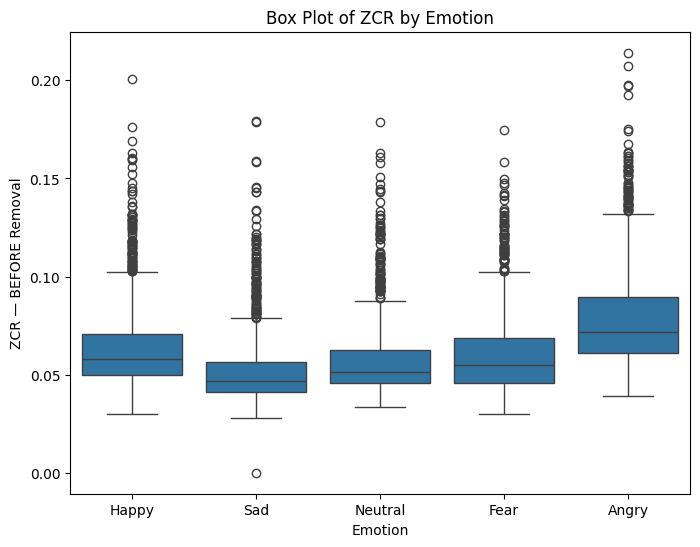

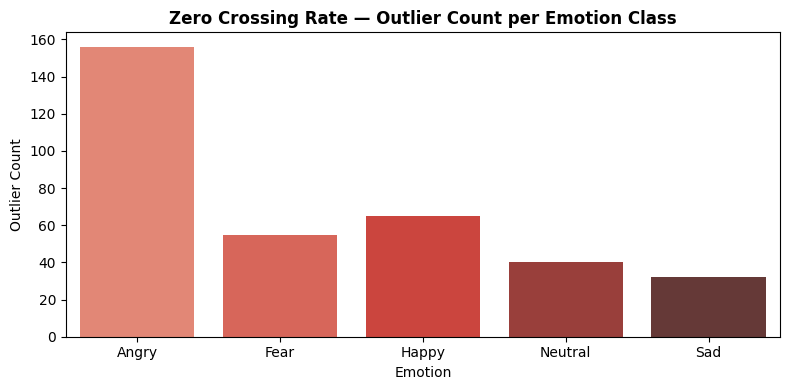


═══════════════════════════════════════════════════════
  Zero Crossing Rate  —  Outlier Summary (IQR Method)
═══════════════════════════════════════════════════════
  Total samples  : 6171
  Total outliers : 348  (5.6%)
  Per-class breakdown:
    Angry     :   66 outliers / 1271 samples
    Fear      :   69 outliers / 1271 samples
    Happy     :   84 outliers / 1271 samples
    Neutral   :   93 outliers / 1087 samples
    Sad       :  103 outliers / 1271 samples


0       False
1       False
2       False
3       False
4       False
        ...  
6166    False
6167    False
6168    False
6169    False
6170    False
Name: ZCR, Length: 6171, dtype: bool

In [6]:
# 3. BEFORE — diagnostics
zcr_df = zcr_df_raw.copy()
print('\nZCR — BEFORE outlier removal')
plot_boxplot(zcr_df, 'ZCR', 'ZCR — BEFORE Removal')
plot_outlier_count_bar(zcr_df, 'ZCR', 'Zero Crossing Rate')
summarise_outliers(zcr_df, 'ZCR', 'Zero Crossing Rate')

In [7]:
# 4. Remove outliers
zcr_df_clean = remove_outliers(zcr_df, 'ZCR')
print(f'\nRows removed : {len(zcr_df) - len(zcr_df_clean)}')
print(f'Shape after  : {zcr_df_clean.shape}')
print(zcr_df_clean['emotion'].value_counts())


Rows removed : 348
Shape after  : (5823, 3)
emotion
Sad        1239
Fear       1216
Happy      1206
Angry      1115
Neutral    1047
Name: count, dtype: int64


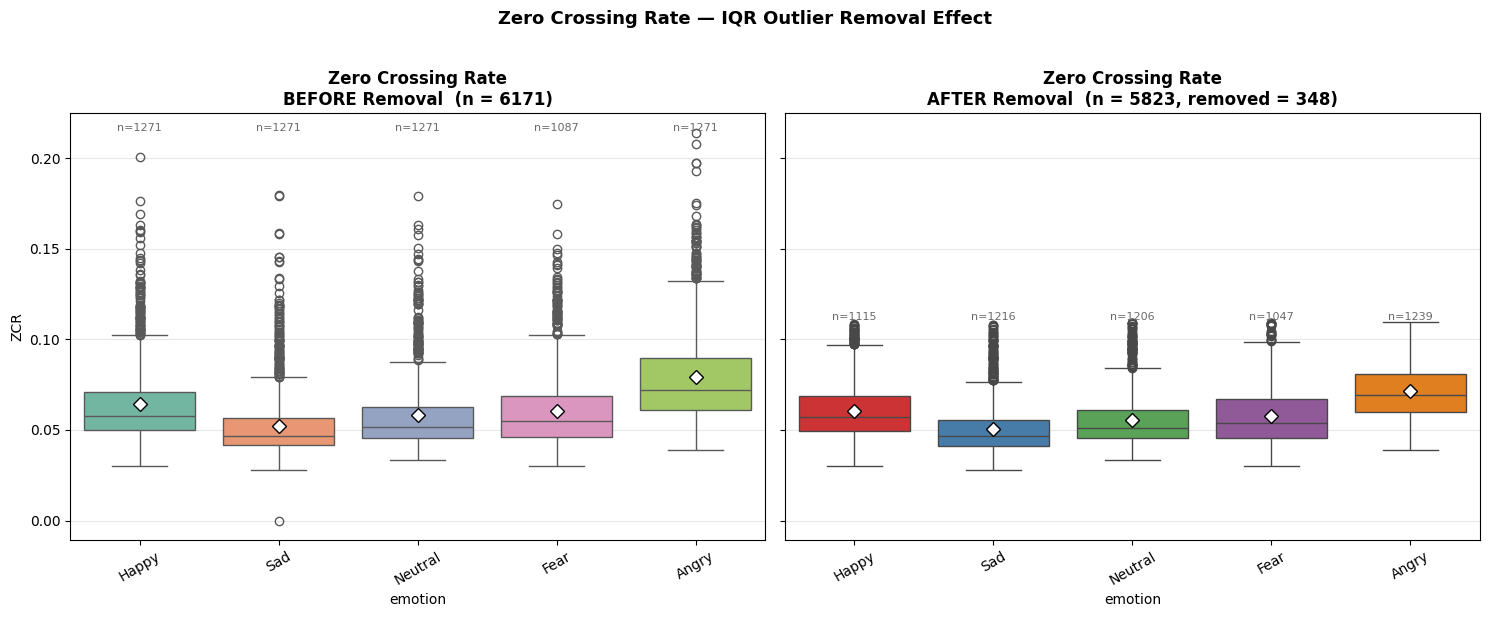

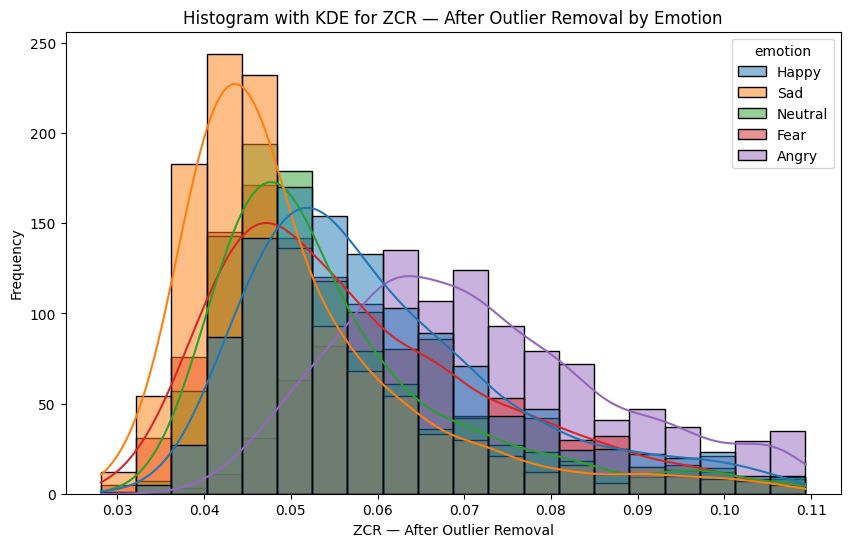

ZCR mega dataset ready: 5823 rows


In [8]:
# 5. AFTER — diagnostics
plot_before_after(zcr_df, zcr_df_clean, 'ZCR', 'Zero Crossing Rate')
plot_histogram_with_kde(zcr_df_clean, 'ZCR', 'ZCR — After Outlier Removal')
print(f'ZCR mega dataset ready: {len(zcr_df_clean)} rows')

### Feature 2 — MFCCs

Mel-Frequency Cepstral Coefficients describe the short-term spectral envelope on the perceptual mel scale. They are the workhorse feature for speech emotion recognition because they capture timbre — the very property that distinguishes an angry voice from a sad one.


In [9]:
# FEATURE 2 — MFCCs (extraction + cleaning in ONE cell)

# 1. Extract — 20 coefficients averaged across time
mfcc_list = []
for _, row in metadata_df.iterrows():
    data, sr = librosa.load(row['file'])
    mfcc = librosa.feature.mfcc(y=data, sr=sr).mean(axis=1)
    mfcc_list.append(list(mfcc) + [row['emotion'], row['file']])

mfcc_columns = [f'MFCC_{i}' for i in range(20)] + ['emotion', 'file']
mfcc_df_raw  = pd.DataFrame(mfcc_list, columns=mfcc_columns)
print(f'MFCC raw shape: {mfcc_df_raw.shape} (full dataset = {len(metadata_df)} files)')
print(mfcc_df_raw['emotion'].value_counts())

MFCC raw shape: (6171, 22) (full dataset = 6171 files)
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


In [10]:
# 2. Drop missing values
n_missing = mfcc_df_raw['MFCC_0'].isna().sum()
if n_missing:
    print(f'Missing values dropped: {n_missing}')
    mfcc_df_raw = mfcc_df_raw.dropna(subset=['MFCC_0']).reset_index(drop=True)


 MFCC — BEFORE outlier removal


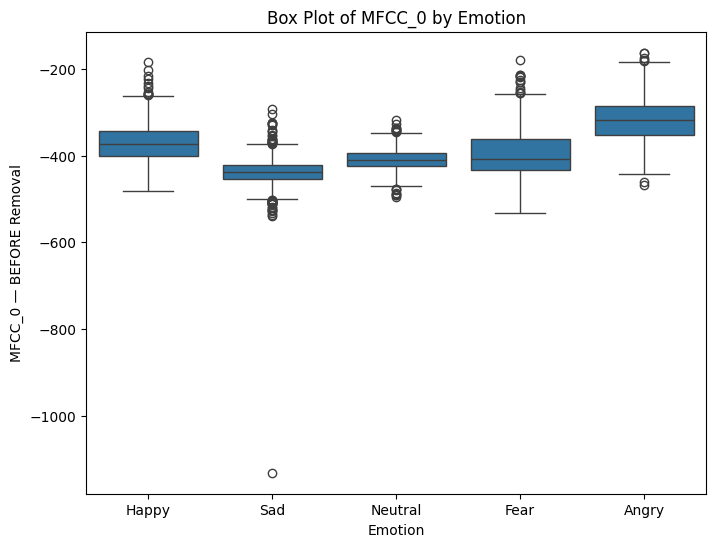

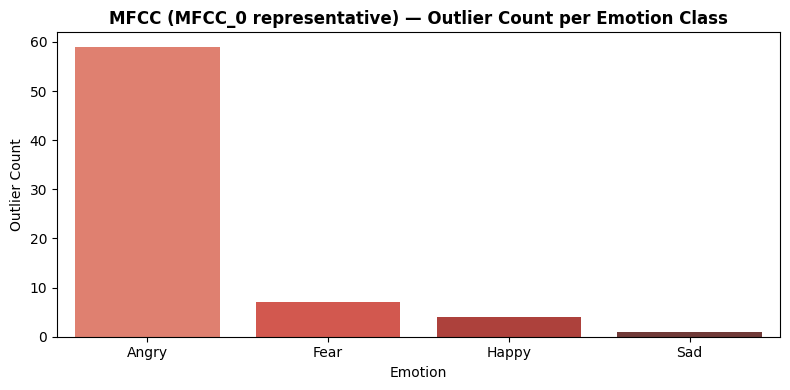


═══════════════════════════════════════════════════════
  MFCC (MFCC_0 representative)  —  Outlier Summary (IQR Method)
═══════════════════════════════════════════════════════
  Total samples  : 6171
  Total outliers : 71  (1.2%)
  Per-class breakdown:
    Angry     :    7 outliers / 1271 samples
    Fear      :   14 outliers / 1271 samples
    Happy     :   13 outliers / 1271 samples
    Neutral   :   18 outliers / 1087 samples
    Sad       :   50 outliers / 1271 samples


0       False
1       False
2       False
3       False
4       False
        ...  
6166    False
6167    False
6168    False
6169    False
6170    False
Name: MFCC_0, Length: 6171, dtype: bool

In [11]:
# 3. BEFORE
mfcc_df = mfcc_df_raw.copy()
print('\n MFCC — BEFORE outlier removal')
plot_boxplot(mfcc_df, 'MFCC_0', 'MFCC_0 — BEFORE Removal')
plot_outlier_count_bar(mfcc_df, 'MFCC_0', 'MFCC (MFCC_0 representative)')
summarise_outliers(mfcc_df, 'MFCC_0', 'MFCC (MFCC_0 representative)')

In [12]:
# 4. Remove outliers (using MFCC_0 as the representative axis)
mfcc_df_clean = remove_outliers(mfcc_df, 'MFCC_0')
print(f'\nRows removed : {len(mfcc_df) - len(mfcc_df_clean)}')
print(f'Shape after  : {mfcc_df_clean.shape}')
print(mfcc_df_clean['emotion'].value_counts())


Rows removed : 71
Shape after  : (6100, 22)
emotion
Sad        1270
Happy      1267
Fear       1264
Angry      1212
Neutral    1087
Name: count, dtype: int64


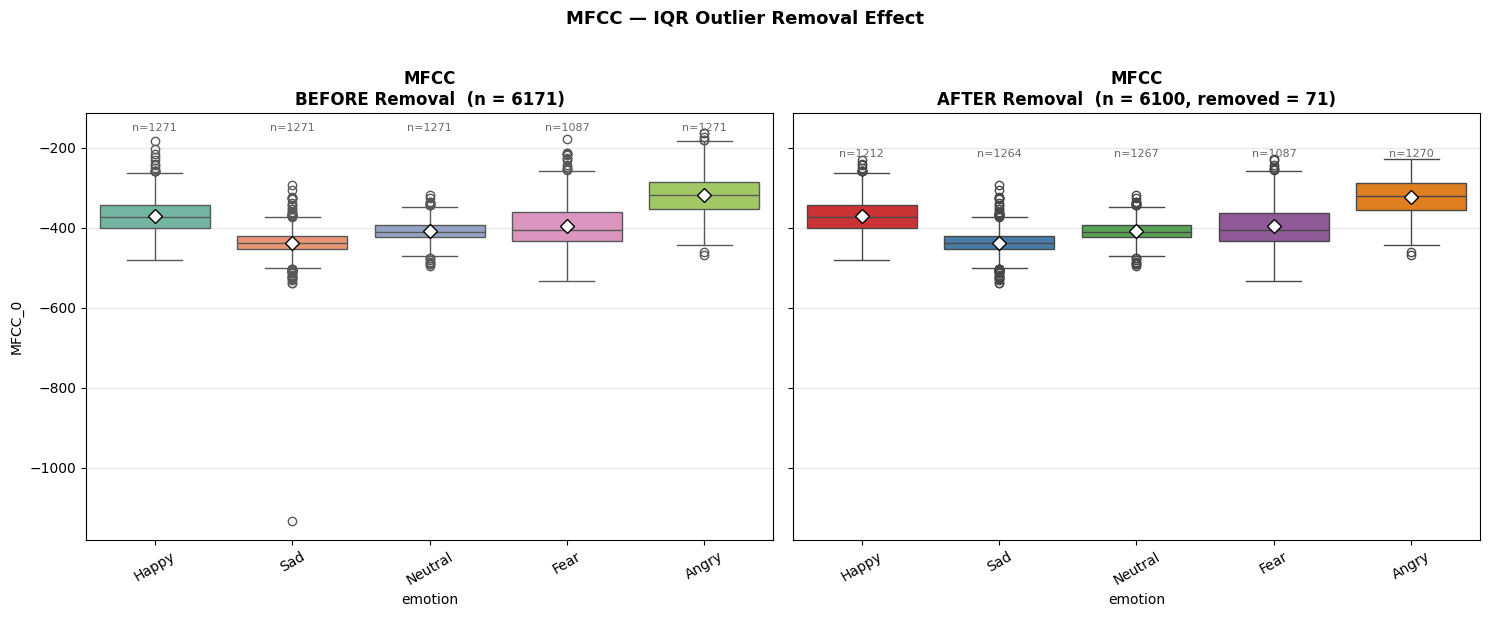

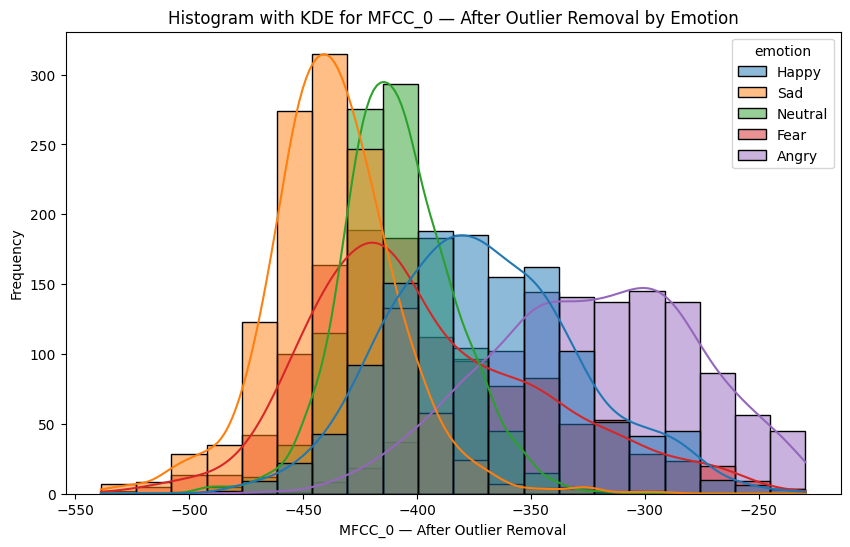

MFCC mega dataset ready: 6100 rows


In [13]:
# 5. AFTER
plot_before_after(mfcc_df, mfcc_df_clean, 'MFCC_0', 'MFCC')
plot_histogram_with_kde(mfcc_df_clean, 'MFCC_0', 'MFCC_0 — After Outlier Removal')
print(f'MFCC mega dataset ready: {len(mfcc_df_clean)} rows')

### Feature 3 — Chroma

Chroma features map the audio onto the 12 pitch classes of the chromatic scale. They expose the tonal/melodic colour of speech, which differs between elated and depressed prosody.


In [14]:
# FEATURE 3 — Chroma (extraction + cleaning in ONE cell)

# 1. Extract — 12 pitch-class energies averaged across time
chroma_list = []
for _, row in metadata_df.iterrows():
    data, sr = librosa.load(row['file'])
    stft = np.abs(librosa.stft(data))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sr).mean(axis=1)
    chroma_list.append(list(chroma) + [row['emotion'], row['file']])

chroma_columns = [f'Chroma_{i}' for i in range(12)] + ['emotion', 'file']
chroma_df_raw  = pd.DataFrame(chroma_list, columns=chroma_columns)
print(f'Chroma raw shape: {chroma_df_raw.shape} (full dataset = {len(metadata_df)} files)')
print(chroma_df_raw['emotion'].value_counts())

Chroma raw shape: (6171, 14) (full dataset = 6171 files)
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


In [15]:
# 2. Drop missing values
n_missing = chroma_df_raw['Chroma_0'].isna().sum()
if n_missing:
    print(f'Missing values dropped: {n_missing}')
    chroma_df_raw = chroma_df_raw.dropna(subset=['Chroma_0']).reset_index(drop=True)


📊 Chroma — BEFORE outlier removal


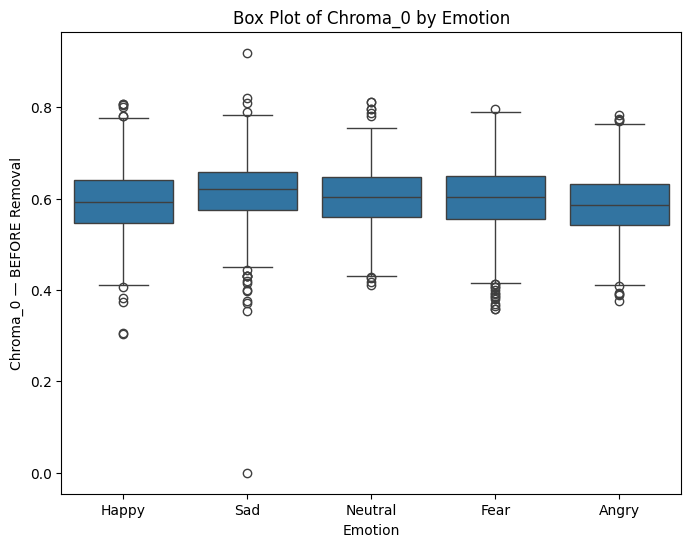

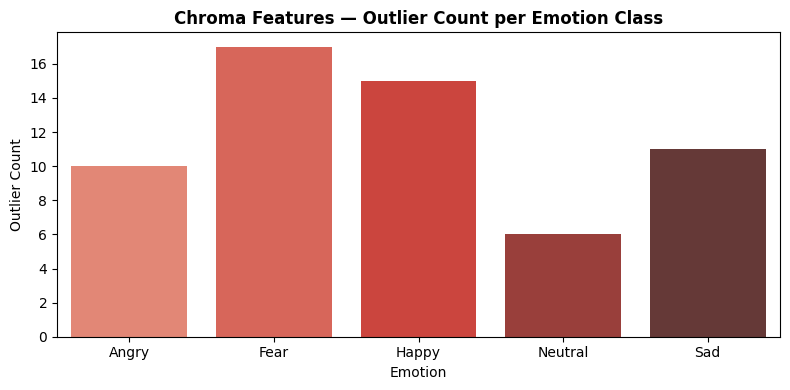


═══════════════════════════════════════════════════════
  Chroma Features  —  Outlier Summary (IQR Method)
═══════════════════════════════════════════════════════
  Total samples  : 6171
  Total outliers : 59  (1.0%)
  Per-class breakdown:
    Angry     :    9 outliers / 1271 samples
    Fear      :   15 outliers / 1271 samples
    Happy     :   11 outliers / 1271 samples
    Neutral   :   10 outliers / 1087 samples
    Sad       :   17 outliers / 1271 samples


0       False
1       False
2       False
3       False
4       False
        ...  
6166    False
6167    False
6168    False
6169    False
6170    False
Name: Chroma_0, Length: 6171, dtype: bool

In [16]:
# 3. BEFORE
chroma_df = chroma_df_raw.copy()
print('\n📊 Chroma — BEFORE outlier removal')
plot_boxplot(chroma_df, 'Chroma_0', 'Chroma_0 — BEFORE Removal')
plot_outlier_count_bar(chroma_df, 'Chroma_0', 'Chroma Features')
summarise_outliers(chroma_df, 'Chroma_0', 'Chroma Features')

In [17]:
# 4. Remove outliers
chroma_df_clean = remove_outliers(chroma_df, 'Chroma_0')
print(f'\nRows removed : {len(chroma_df) - len(chroma_df_clean)}')
print(f'Shape after  : {chroma_df_clean.shape}')
print(chroma_df_clean['emotion'].value_counts())


Rows removed : 59
Shape after  : (6112, 14)
emotion
Angry      1261
Sad        1260
Happy      1256
Fear       1254
Neutral    1081
Name: count, dtype: int64


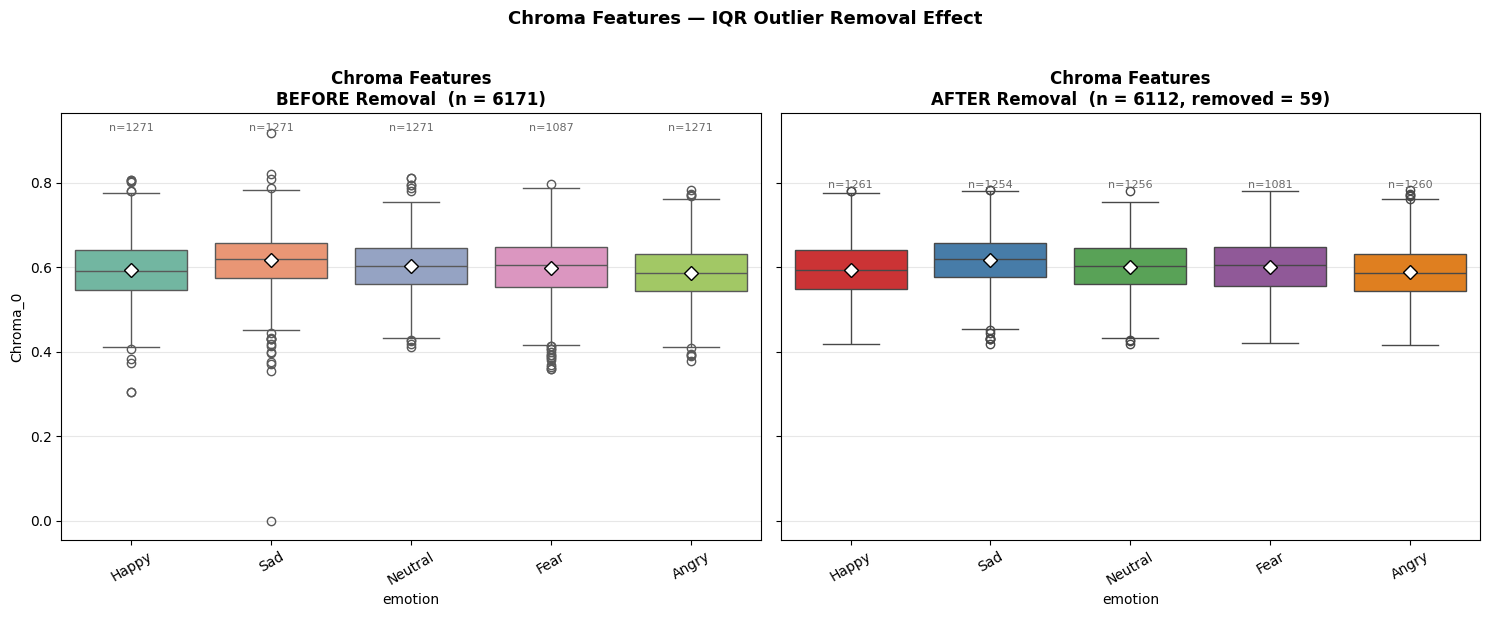

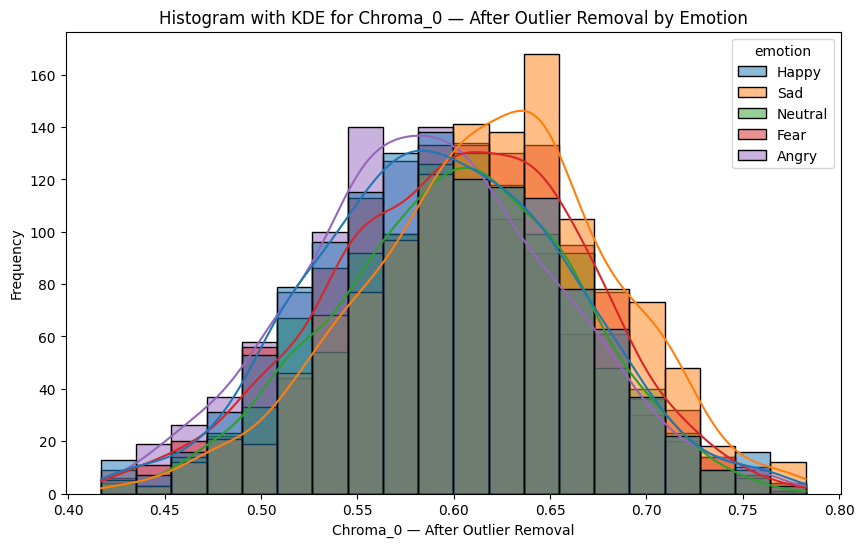

✅ Chroma mega dataset ready: 6112 rows


In [18]:
# 5. AFTER
plot_before_after(chroma_df, chroma_df_clean, 'Chroma_0', 'Chroma Features')
plot_histogram_with_kde(chroma_df_clean, 'Chroma_0', 'Chroma_0 — After Outlier Removal')
print(f'✅ Chroma mega dataset ready: {len(chroma_df_clean)} rows')

### Feature 4 — RMS Energy

Root-mean-square energy is the average loudness of the clip. Loud emotions (Angry, Happy) sit far above quiet ones (Sad), so RMS gives a strong scalar baseline cue.


In [19]:
# FEATURE 4 — Root Mean Square Energy (extraction + cleaning in ONE cell)

# 1. Extract
rms_list = []
for _, row in metadata_df.iterrows():
    data, sr = librosa.load(row['file'])
    rms_list.append([librosa.feature.rms(y=data).mean(), row['emotion'], row['file']])

rms_df_raw = pd.DataFrame(rms_list, columns=['RMS', 'emotion', 'file'])
print(f'RMS raw shape: {rms_df_raw.shape} (full dataset = {len(metadata_df)} files)')
print(rms_df_raw['emotion'].value_counts())


RMS raw shape: (6171, 3) (full dataset = 6171 files)
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


In [20]:

# 2. Drop missing values
n_missing = rms_df_raw['RMS'].isna().sum()
if n_missing:
    print(f'Missing values dropped: {n_missing}')
    rms_df_raw = rms_df_raw.dropna(subset=['RMS']).reset_index(drop=True)


 RMS — BEFORE outlier removal


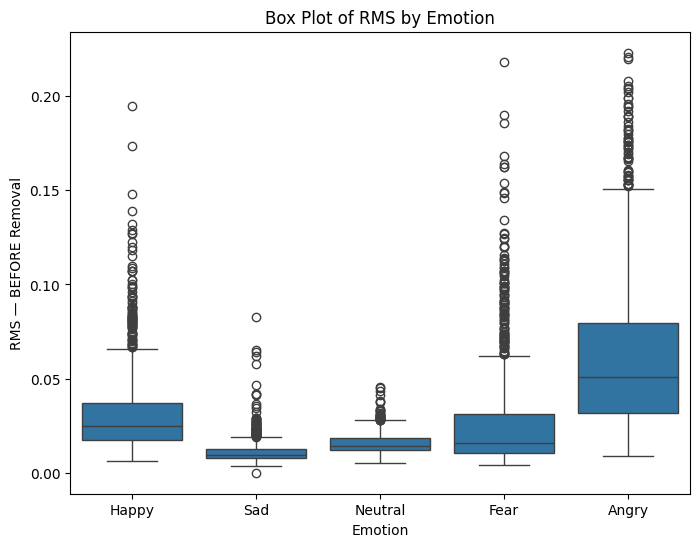

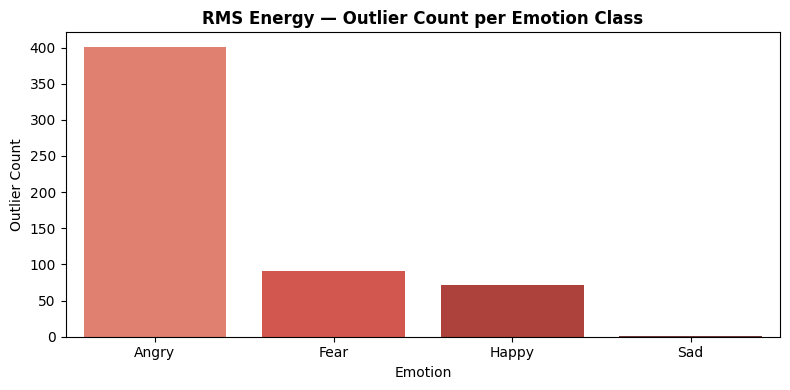


═══════════════════════════════════════════════════════
  RMS Energy  —  Outlier Summary (IQR Method)
═══════════════════════════════════════════════════════
  Total samples  : 6171
  Total outliers : 564  (9.1%)
  Per-class breakdown:
    Angry     :   59 outliers / 1271 samples
    Fear      :  109 outliers / 1271 samples
    Happy     :   81 outliers / 1271 samples
    Neutral   :   32 outliers / 1087 samples
    Sad       :   78 outliers / 1271 samples


0       False
1       False
2       False
3       False
4       False
        ...  
6166    False
6167    False
6168    False
6169    False
6170    False
Name: RMS, Length: 6171, dtype: bool

In [21]:
# 3. BEFORE
rms_df = rms_df_raw.copy()
print('\n RMS — BEFORE outlier removal')
plot_boxplot(rms_df, 'RMS', 'RMS — BEFORE Removal')
plot_outlier_count_bar(rms_df, 'RMS', 'RMS Energy')
summarise_outliers(rms_df, 'RMS', 'RMS Energy')

In [22]:
# 4. Remove outliers
rms_df_clean = remove_outliers(rms_df, 'RMS')
print(f'\nRows removed : {len(rms_df) - len(rms_df_clean)}')
print(f'Shape after  : {rms_df_clean.shape}')
print(rms_df_clean['emotion'].value_counts())


Rows removed : 564
Shape after  : (5607, 3)
emotion
Sad        1270
Happy      1200
Fear       1180
Neutral    1087
Angry       870
Name: count, dtype: int64


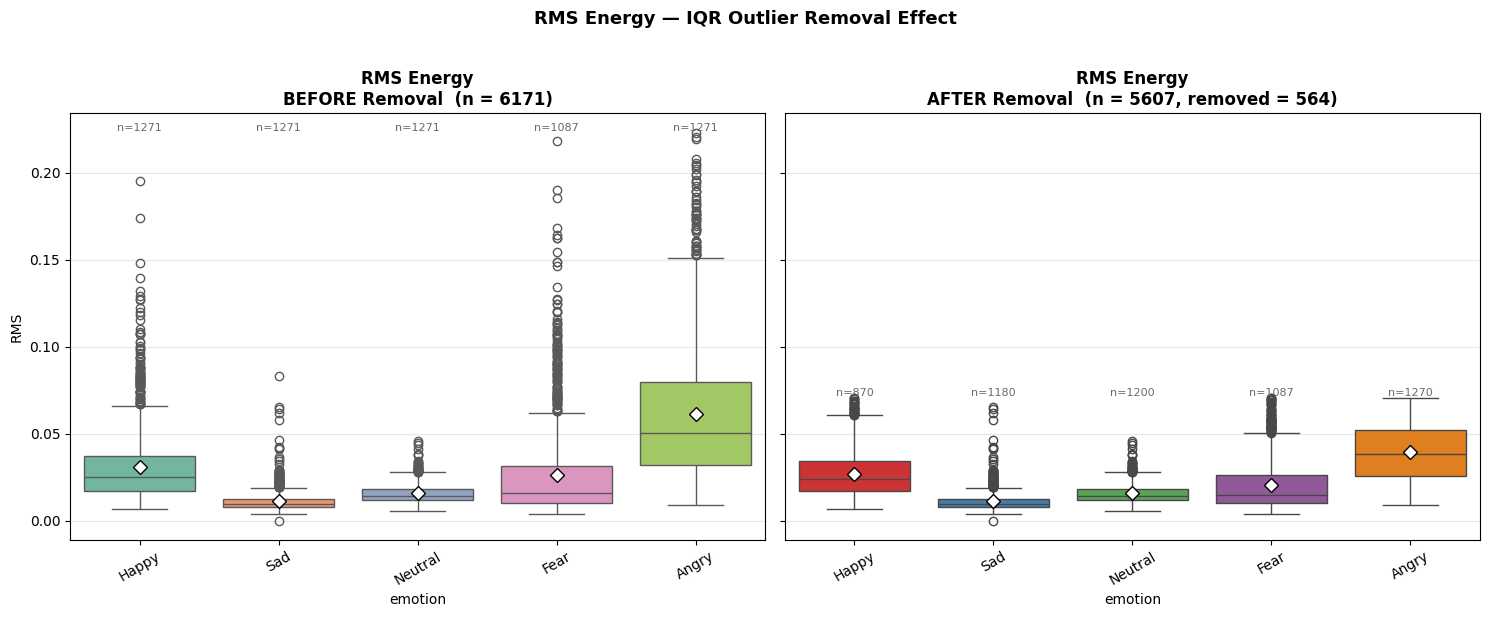

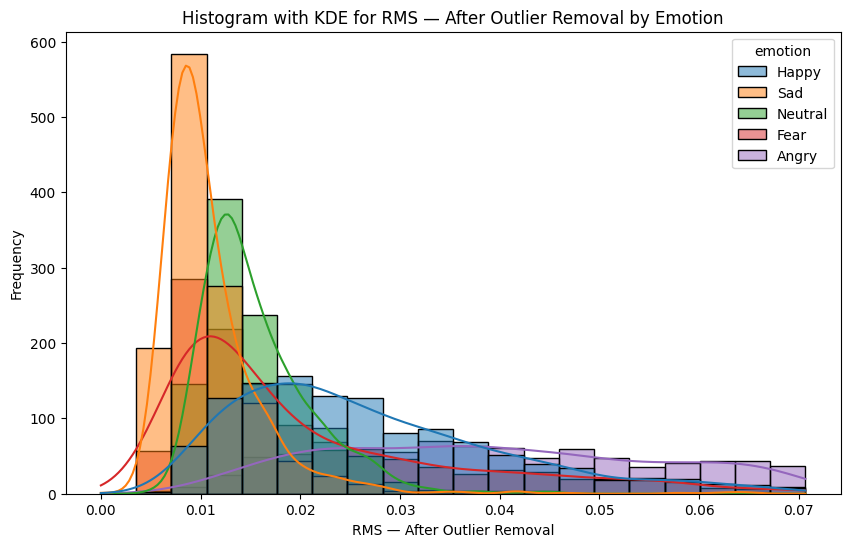

 RMS mega dataset ready: 5607 rows


In [23]:
# 5. AFTER
plot_before_after(rms_df, rms_df_clean, 'RMS', 'RMS Energy')
plot_histogram_with_kde(rms_df_clean, 'RMS', 'RMS — After Outlier Removal')
print(f' RMS mega dataset ready: {len(rms_df_clean)} rows')

### Feature 5 — Mel Spectrogram

The mean energy of a mel-scaled spectrogram. It complements MFCCs by retaining absolute spectral energy information rather than only the cepstral envelope.


In [24]:
# FEATURE 5 — Mel Spectrogram (extraction + cleaning in ONE cell)

# 1. Extract
mel_list = []
for _, row in metadata_df.iterrows():
    data, sr = librosa.load(row['file'])
    mel_list.append([librosa.feature.melspectrogram(y=data, sr=sr).mean(),
                     row['emotion'], row['file']])

mel_df_raw = pd.DataFrame(mel_list, columns=['Mel', 'emotion', 'file'])
print(f'Mel raw shape: {mel_df_raw.shape} (full dataset = {len(metadata_df)} files)')
print(mel_df_raw['emotion'].value_counts())

Mel raw shape: (6171, 3) (full dataset = 6171 files)
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


In [25]:
# 2. Drop missing values
n_missing = mel_df_raw['Mel'].isna().sum()
if n_missing:
    print(f'Missing values dropped: {n_missing}')
    mel_df_raw = mel_df_raw.dropna(subset=['Mel']).reset_index(drop=True)


Mel — BEFORE outlier removal


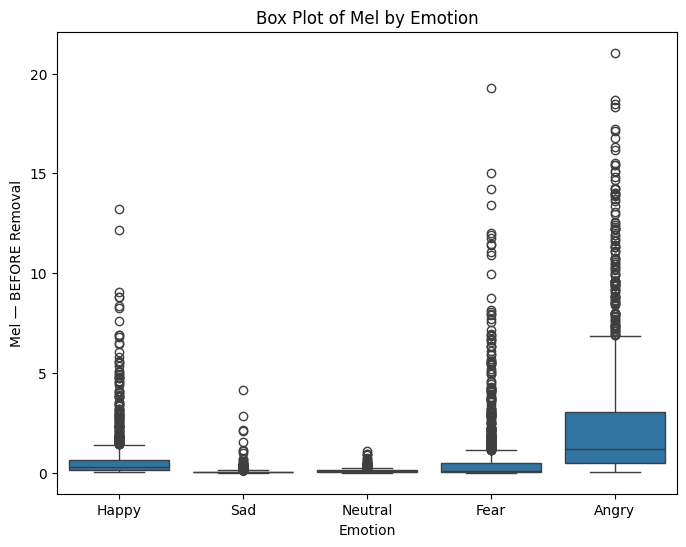

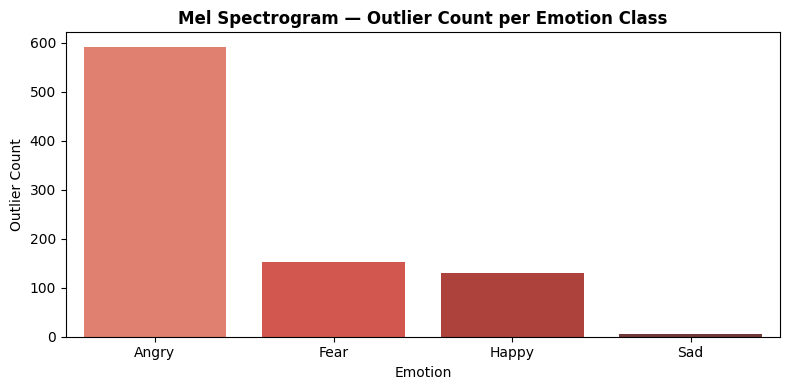


═══════════════════════════════════════════════════════
  Mel Spectrogram  —  Outlier Summary (IQR Method)
═══════════════════════════════════════════════════════
  Total samples  : 6171
  Total outliers : 880  (14.3%)
  Per-class breakdown:
    Angry     :  122 outliers / 1271 samples
    Fear      :  185 outliers / 1271 samples
    Happy     :  122 outliers / 1271 samples
    Neutral   :   87 outliers / 1087 samples
    Sad       :  121 outliers / 1271 samples


0       False
1       False
2       False
3       False
4       False
        ...  
6166    False
6167     True
6168    False
6169    False
6170    False
Name: Mel, Length: 6171, dtype: bool

In [26]:
# 3. BEFORE
mel_df = mel_df_raw.copy()
print('\nMel — BEFORE outlier removal')
plot_boxplot(mel_df, 'Mel', 'Mel — BEFORE Removal')
plot_outlier_count_bar(mel_df, 'Mel', 'Mel Spectrogram')
summarise_outliers(mel_df, 'Mel', 'Mel Spectrogram')

In [27]:
# 4. Remove outliers
mel_df_clean = remove_outliers(mel_df, 'Mel')
print(f'\nRows removed : {len(mel_df) - len(mel_df_clean)}')
print(f'Shape after  : {mel_df_clean.shape}')
print(mel_df_clean['emotion'].value_counts())


Rows removed : 880
Shape after  : (5291, 3)
emotion
Sad        1266
Happy      1140
Fear       1119
Neutral    1087
Angry       679
Name: count, dtype: int64


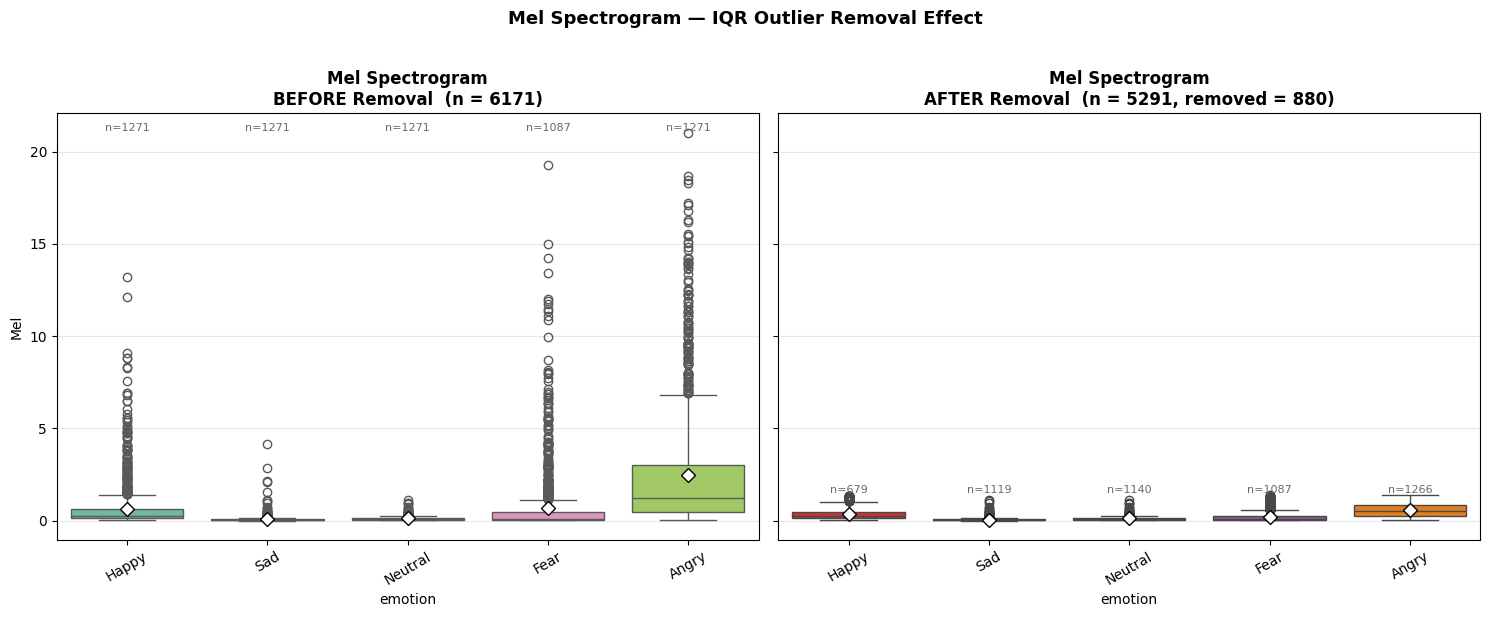

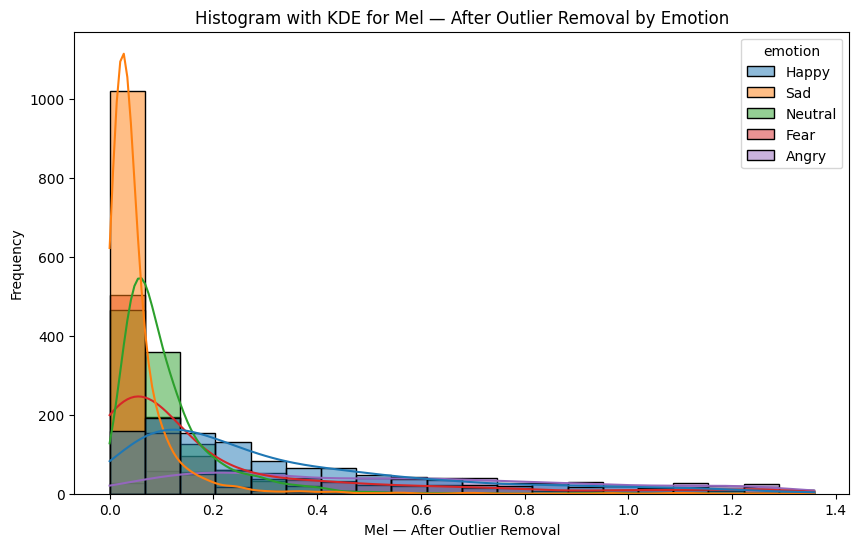

Mel mega dataset ready: 5291 rows


In [28]:
# 5. AFTER
plot_before_after(mel_df, mel_df_clean, 'Mel', 'Mel Spectrogram')
plot_histogram_with_kde(mel_df_clean, 'Mel', 'Mel — After Outlier Removal')
print(f'Mel mega dataset ready: {len(mel_df_clean)} rows')

### Feature 6 — Spectral Centroid

The "centre of mass" of the spectrum. Higher values mean a brighter sound — excited speech (Happy, Angry) shifts the centroid upward; flat/sad speech keeps it low.


In [29]:
# FEATURE 6 — Spectral Centroid (extraction + cleaning in ONE cell)

# 1. Extract
sc_list = []
for _, row in metadata_df.iterrows():
    data, sr = librosa.load(row['file'])
    sc_list.append([librosa.feature.spectral_centroid(y=data, sr=sr).mean(),
                    row['emotion'], row['file']])

spectral_centroid_df_raw = pd.DataFrame(sc_list,
    columns=['Spectral Centroid', 'emotion', 'file'])
print(f'Spectral Centroid raw shape: {spectral_centroid_df_raw.shape} (full dataset = {len(metadata_df)} files)')
print(spectral_centroid_df_raw['emotion'].value_counts())


Spectral Centroid raw shape: (6171, 3) (full dataset = 6171 files)
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


In [30]:
# 2. Drop missing values
n_missing = spectral_centroid_df_raw['Spectral Centroid'].isna().sum()
if n_missing:
    print(f'Missing values dropped: {n_missing}')
    spectral_centroid_df_raw = spectral_centroid_df_raw.dropna(
        subset=['Spectral Centroid']).reset_index(drop=True)


📊 Spectral Centroid — BEFORE outlier removal


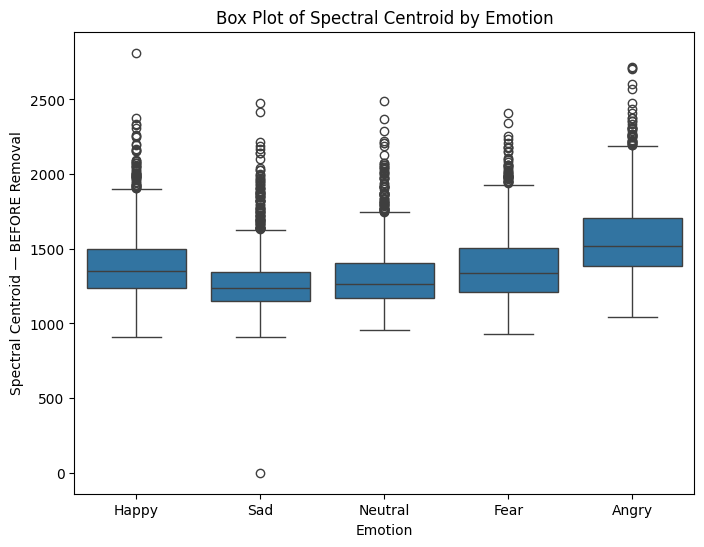

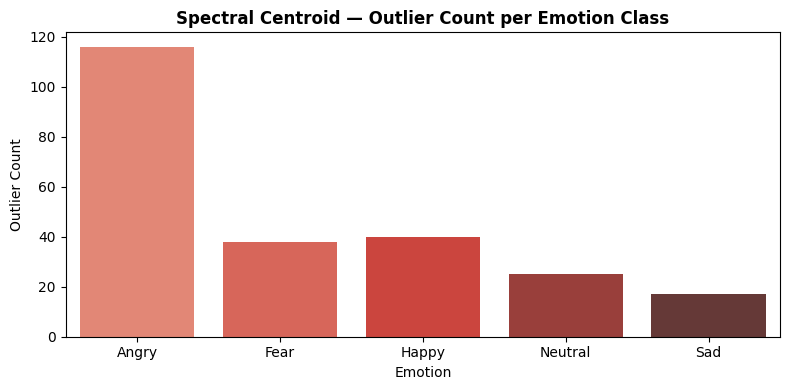


═══════════════════════════════════════════════════════
  Spectral Centroid  —  Outlier Summary (IQR Method)
═══════════════════════════════════════════════════════
  Total samples  : 6171
  Total outliers : 236  (3.8%)
  Per-class breakdown:
    Angry     :   37 outliers / 1271 samples
    Fear      :   44 outliers / 1271 samples
    Happy     :   53 outliers / 1271 samples
    Neutral   :   69 outliers / 1087 samples
    Sad       :   85 outliers / 1271 samples


0       False
1       False
2       False
3       False
4       False
        ...  
6166    False
6167    False
6168    False
6169    False
6170    False
Name: Spectral Centroid, Length: 6171, dtype: bool

In [31]:
# 3. BEFORE
spectral_centroid_df = spectral_centroid_df_raw.copy()
print('\n📊 Spectral Centroid — BEFORE outlier removal')
plot_boxplot(spectral_centroid_df, 'Spectral Centroid', 'Spectral Centroid — BEFORE Removal')
plot_outlier_count_bar(spectral_centroid_df, 'Spectral Centroid', 'Spectral Centroid')
summarise_outliers(spectral_centroid_df, 'Spectral Centroid', 'Spectral Centroid')

In [32]:
# 4. Remove outliers
spectral_centroid_df_clean = remove_outliers(spectral_centroid_df, 'Spectral Centroid')
print(f'\nRows removed : {len(spectral_centroid_df) - len(spectral_centroid_df_clean)}')
print(f'Shape after  : {spectral_centroid_df_clean.shape}')
print(spectral_centroid_df_clean['emotion'].value_counts())


Rows removed : 236
Shape after  : (5935, 3)
emotion
Sad        1254
Fear       1233
Happy      1231
Angry      1155
Neutral    1062
Name: count, dtype: int64


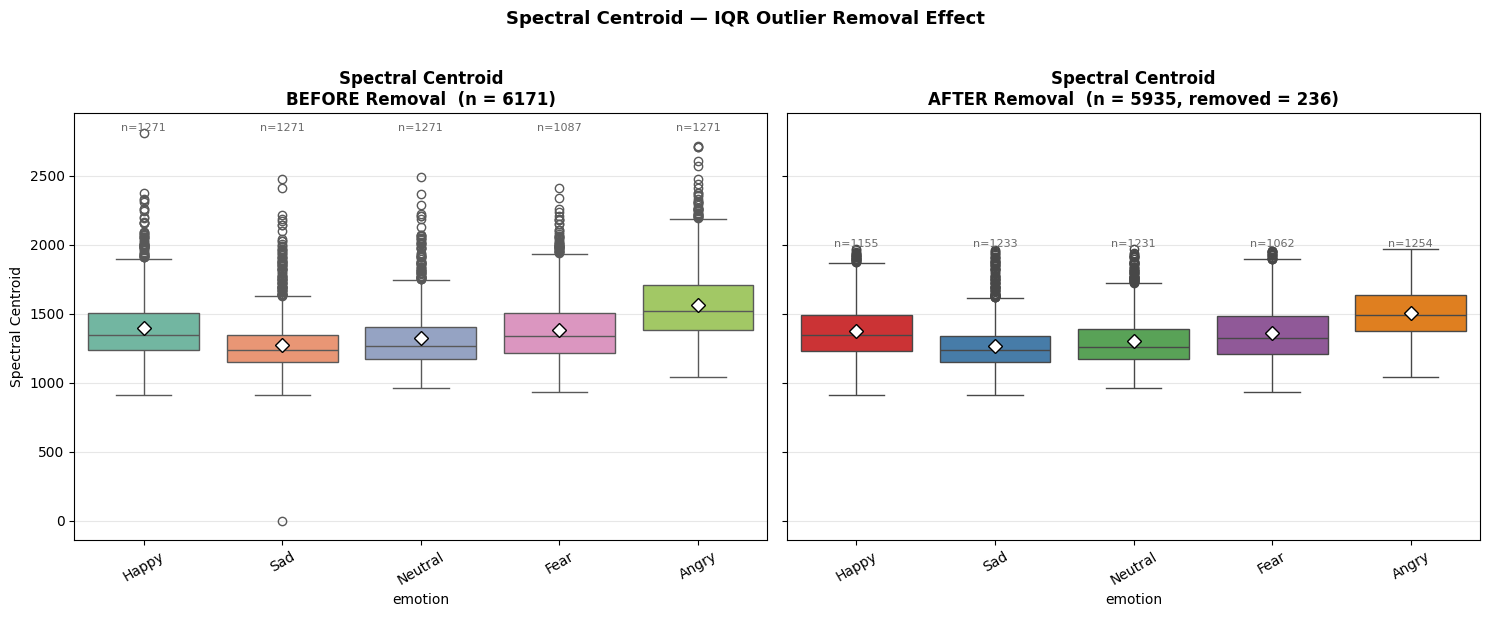

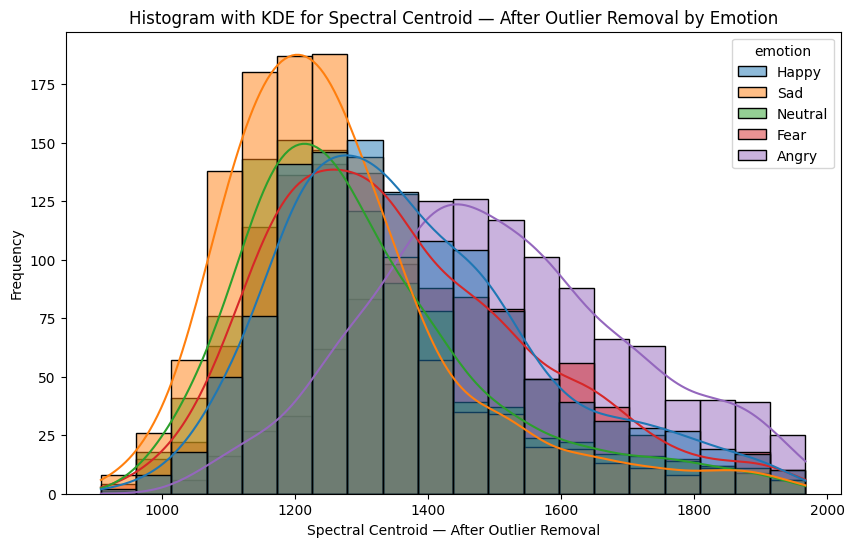

Spectral Centroid mega dataset ready: 5935 rows


In [33]:
# 5. AFTER
plot_before_after(spectral_centroid_df, spectral_centroid_df_clean,
                  'Spectral Centroid', 'Spectral Centroid')
plot_histogram_with_kde(spectral_centroid_df_clean, 'Spectral Centroid',
                        'Spectral Centroid — After Outlier Removal')
print(f'Spectral Centroid mega dataset ready: {len(spectral_centroid_df_clean)} rows')

### Feature 7 — Spectral Bandwidth

The spread of frequencies around the centroid. Wider bandwidth indicates more spectral energy distributed across the band, which is typical of agitated emotions (Angry, Fear).


In [34]:
# FEATURE 7 — Spectral Bandwidth (extraction + cleaning in ONE cell)

# 1. Extract
sb_list = []
for _, row in metadata_df.iterrows():
    data, sr = librosa.load(row['file'])
    sb_list.append([librosa.feature.spectral_bandwidth(y=data, sr=sr).mean(),
                    row['emotion'], row['file']])

spectral_bandwidth_df_raw = pd.DataFrame(sb_list,
    columns=['Spectral Bandwidth', 'emotion', 'file'])
print(f'Spectral Bandwidth raw shape: {spectral_bandwidth_df_raw.shape} (full dataset = {len(metadata_df)} files)')
print(spectral_bandwidth_df_raw['emotion'].value_counts())

Spectral Bandwidth raw shape: (6171, 3) (full dataset = 6171 files)
emotion
Happy      1271
Sad        1271
Fear       1271
Angry      1271
Neutral    1087
Name: count, dtype: int64


In [35]:
# 2. Drop missing values
n_missing = spectral_bandwidth_df_raw['Spectral Bandwidth'].isna().sum()
if n_missing:
    print(f'Missing values dropped: {n_missing}')
    spectral_bandwidth_df_raw = spectral_bandwidth_df_raw.dropna(
        subset=['Spectral Bandwidth']).reset_index(drop=True)


 Spectral Bandwidth — BEFORE outlier removal


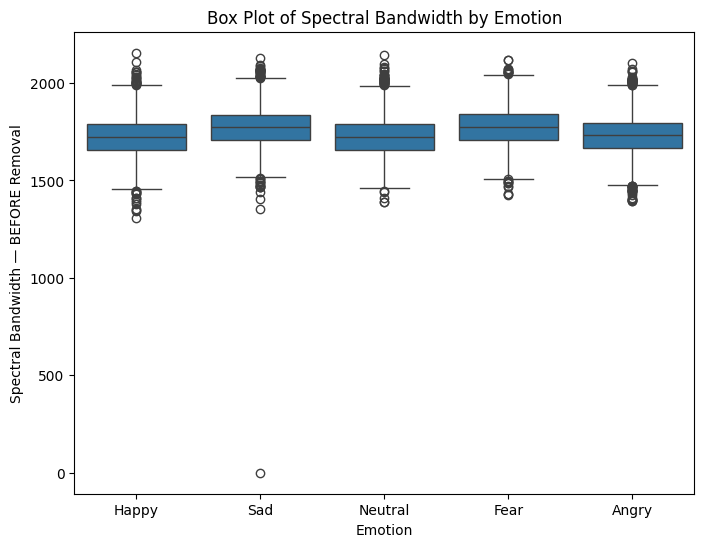

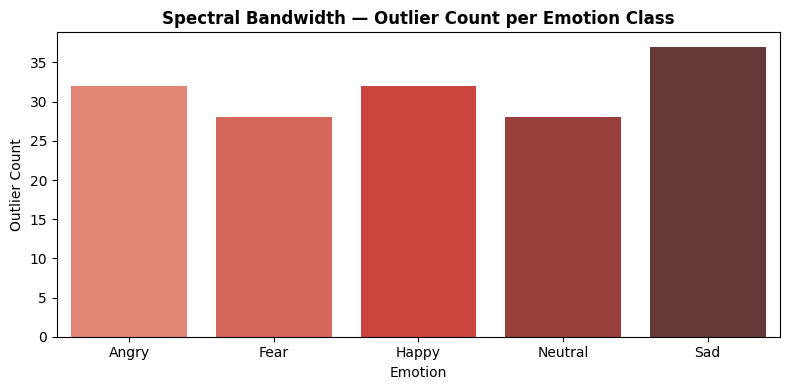


═══════════════════════════════════════════════════════
  Spectral Bandwidth  —  Outlier Summary (IQR Method)
═══════════════════════════════════════════════════════
  Total samples  : 6171
  Total outliers : 157  (2.5%)
  Per-class breakdown:
    Angry     :   55 outliers / 1271 samples
    Fear      :   23 outliers / 1271 samples
    Happy     :   38 outliers / 1271 samples
    Neutral   :   42 outliers / 1087 samples
    Sad       :   45 outliers / 1271 samples


0       False
1       False
2       False
3       False
4       False
        ...  
6166    False
6167    False
6168    False
6169    False
6170    False
Name: Spectral Bandwidth, Length: 6171, dtype: bool

In [36]:
# 3. BEFORE
spectral_bandwidth_df = spectral_bandwidth_df_raw.copy()
print('\n Spectral Bandwidth — BEFORE outlier removal')
plot_boxplot(spectral_bandwidth_df, 'Spectral Bandwidth', 'Spectral Bandwidth — BEFORE Removal')
plot_outlier_count_bar(spectral_bandwidth_df, 'Spectral Bandwidth', 'Spectral Bandwidth')
summarise_outliers(spectral_bandwidth_df, 'Spectral Bandwidth', 'Spectral Bandwidth')

In [37]:
# 4. Remove outliers
spectral_bandwidth_df_clean = remove_outliers(spectral_bandwidth_df, 'Spectral Bandwidth')
print(f'\nRows removed : {len(spectral_bandwidth_df) - len(spectral_bandwidth_df_clean)}')
print(f'Shape after  : {spectral_bandwidth_df_clean.shape}')
print(spectral_bandwidth_df_clean['emotion'].value_counts())


Rows removed : 157
Shape after  : (6014, 3)
emotion
Fear       1243
Happy      1239
Angry      1239
Sad        1234
Neutral    1059
Name: count, dtype: int64


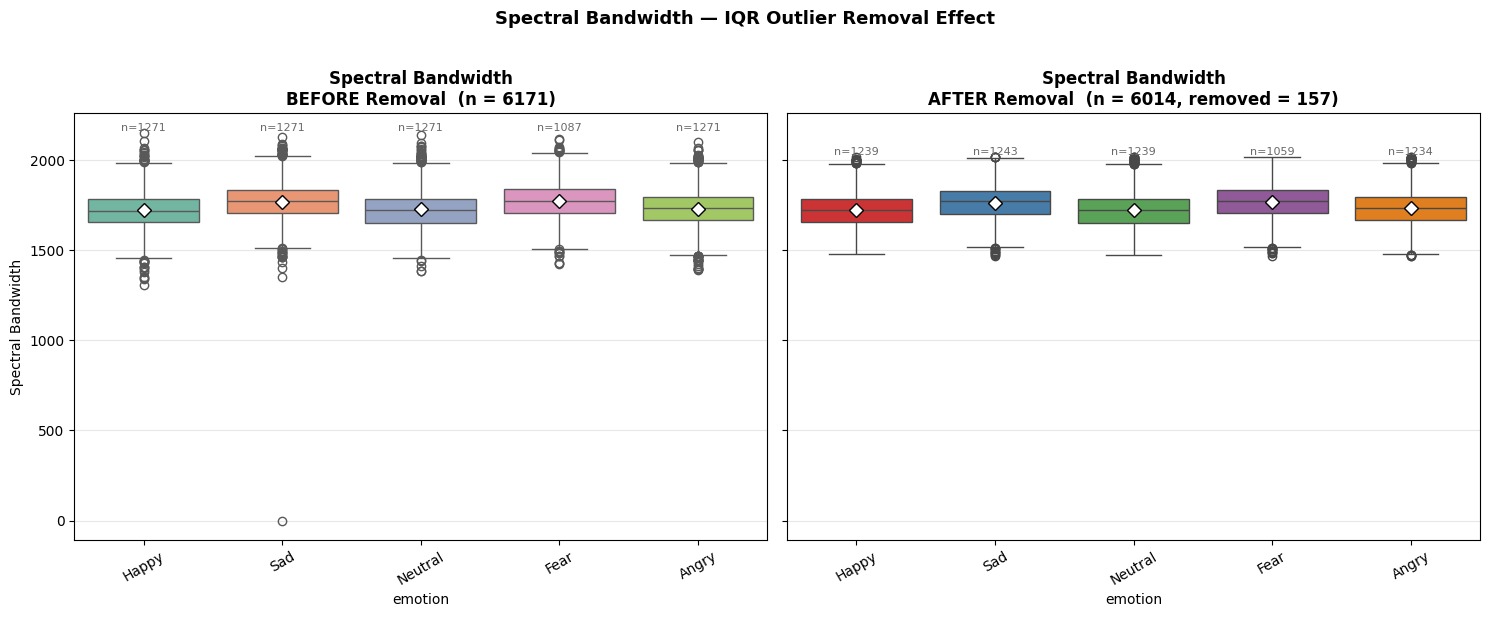

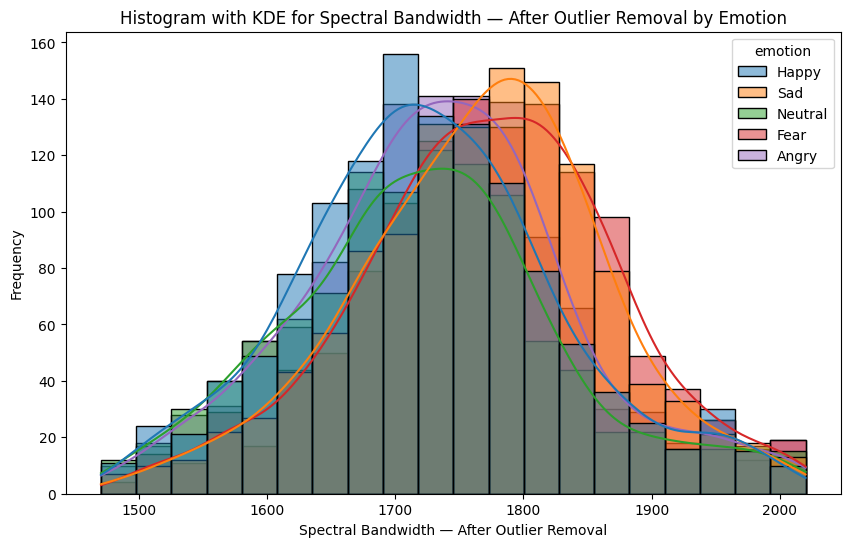

Spectral Bandwidth mega dataset ready: 6014 rows


In [38]:
# 5. AFTER
plot_before_after(spectral_bandwidth_df, spectral_bandwidth_df_clean,
                  'Spectral Bandwidth', 'Spectral Bandwidth')
plot_histogram_with_kde(spectral_bandwidth_df_clean, 'Spectral Bandwidth',
                        'Spectral Bandwidth — After Outlier Removal')
print(f'Spectral Bandwidth mega dataset ready: {len(spectral_bandwidth_df_clean)} rows')

## Step 4 — Independent Extraction Summary

Compares how many files survived each feature's outlier filter. Because the seven extractions are independent, the surviving file lists overlap only partially — this is what makes the inner-join in Step 5 meaningful.



════════════════════════════════════════════════════════════
  INDEPENDENT EXTRACTION — Mega Dataset Sizes
  (All started from the same full dataset — NO cascading)
════════════════════════════════════════════════════════════
  Original                 :   6171
  ZCR                      :   5823  (removed 348)
  MFCC                     :   6100  (removed 71)
  Chroma                   :   6112  (removed 59)
  RMS                      :   5607  (removed 564)
  Mel                      :   5291  (removed 880)
  Spectral Centroid        :   5935  (removed 236)
  Spectral Bandwidth       :   6014  (removed 157)


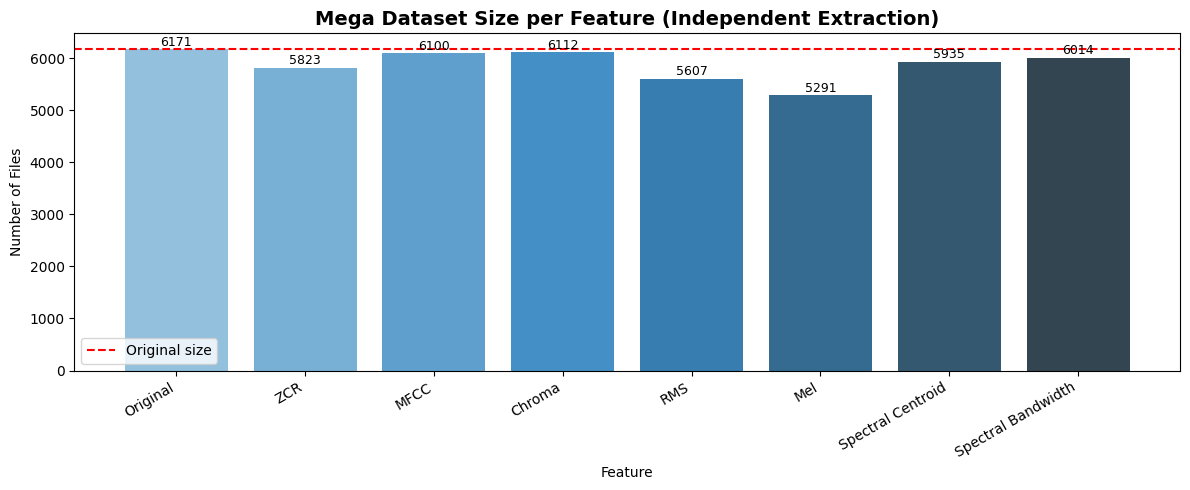

In [39]:
#  INDEPENDENT EXTRACTION SUMMARY

mega_datasets = {
    'ZCR'               : zcr_df_clean,
    'MFCC'              : mfcc_df_clean,
    'Chroma'            : chroma_df_clean,
    'RMS'               : rms_df_clean,
    'Mel'               : mel_df_clean,
    'Spectral Centroid' : spectral_centroid_df_clean,
    'Spectral Bandwidth': spectral_bandwidth_df_clean,
}

print('\n' + '═'*60)
print('  INDEPENDENT EXTRACTION — Mega Dataset Sizes')
print('  (All started from the same full dataset — NO cascading)')
print('═'*60)
print(f'  {"Original":25s}: {len(metadata_df):6d}')
for name, df in mega_datasets.items():
    removed = len(metadata_df) - len(df)
    print(f'  {name:25s}: {len(df):6d}  (removed {removed})')

plt.figure(figsize=(12, 5))
labels = ['Original'] + list(mega_datasets.keys())
sizes  = [len(metadata_df)] + [len(df) for df in mega_datasets.values()]
colors = sns.color_palette('Blues_d', len(labels))
bars   = plt.bar(labels, sizes, color=colors)
plt.axhline(y=len(metadata_df), color='red', linestyle='--', linewidth=1.5, label='Original size')
plt.title('Mega Dataset Size per Feature (Independent Extraction)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Files'); plt.xlabel('Feature')
plt.xticks(rotation=30, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.legend(); plt.tight_layout(); plt.show()

## Step 5 — Merge Mega Datasets into One Final Dataset

Strategy: **inner join** on `file` — keep only files that are clean across ALL features. This is the most conservative approach and maximises data quality for model training.


In [40]:
#  BUILD FINAL MERGED MEGA DATASET

# Compute the intersection of surviving files across all features
clean_file_sets = {name: set(df['file'].tolist()) for name, df in mega_datasets.items()}
final_clean_files = set.intersection(*clean_file_sets.values())

print(f'Files clean in ALL 7 features: {len(final_clean_files)}')
print(f'Original dataset            : {len(metadata_df)}')
print(f'Total removed               : {len(metadata_df) - len(final_clean_files)}')

# Per-feature contribution to exclusions
print('\nFiles excluded by each feature independently:')
for name, file_set in clean_file_sets.items():
    excluded = len(metadata_df) - len(file_set)
    print(f'  {name:25s}: {excluded} files excluded')

Files clean in ALL 7 features: 4919
Original dataset            : 6171
Total removed               : 1252

Files excluded by each feature independently:
  ZCR                      : 348 files excluded
  MFCC                     : 71 files excluded
  Chroma                   : 59 files excluded
  RMS                      : 564 files excluded
  Mel                      : 880 files excluded
  Spectral Centroid        : 236 files excluded
  Spectral Bandwidth       : 157 files excluded


### Build Final Feature Tensors

From the merged-clean file list we now produce two parallel tensors:

- `X_seq` of shape `(n, 128, 40)` — MFCC sequence used by the recurrent / convolutional branches.
- `X_scalar` of shape `(n, 7)` — the seven hand-crafted scalar features used by the dense scalar branch.


In [41]:
#  EXTRACT FINAL FEATURES FROM MERGED CLEAN FILE LIST
#  Build sequence (MFCC 128×40) + scalar (7 features) arrays for model training

metadata_final = metadata_df[
    metadata_df['file'].isin(final_clean_files)
].reset_index(drop=True)

print(f'Extracting SEQUENCE + SCALAR features from {len(metadata_final)} merged-clean files...')

all_sequences = []   # shape: (n_files, N_FRAMES, N_MFCC)
all_scalars   = []   # shape: (n_files, 7)
all_labels    = []

for idx, (_, row) in enumerate(metadata_final.iterrows()):
    if idx % 500 == 0:
        print(f'  Processing file {idx}/{len(metadata_final)} ...')
    try:
        y, sr = librosa.load(row['file'], sr=22050)
        stft  = np.abs(librosa.stft(y))

        # SEQUENCE: 40-coeff MFCC matrix fixed to N_FRAMES
        mfcc_seq = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)  # (40, T)
        if mfcc_seq.shape[1] < N_FRAMES:
            pad = N_FRAMES - mfcc_seq.shape[1]
            mfcc_seq = np.pad(mfcc_seq, ((0, 0), (0, pad)), mode='constant')
        else:
            mfcc_seq = mfcc_seq[:, :N_FRAMES]
        mfcc_seq = mfcc_seq.T   # → (N_FRAMES, N_MFCC)

        # SCALARS: 7 independently-cleaned features
        chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
        scalars = np.array([
            librosa.feature.zero_crossing_rate(y=y).mean(),
            librosa.feature.rms(y=y).mean(),
            librosa.feature.melspectrogram(y=y, sr=sr).mean(),
            librosa.feature.spectral_centroid(y=y, sr=sr).mean(),
            librosa.feature.spectral_bandwidth(y=y, sr=sr).mean(),
            chroma.mean(),
            chroma.std(),
        ], dtype=np.float32)

        all_sequences.append(mfcc_seq.astype(np.float32))
        all_scalars.append(scalars)
        all_labels.append(row['emotion'])
    except Exception as e:
        print(f'  Skipped {row["file"]}: {e}')

X_seq    = np.array(all_sequences)  # (n, 128, 40)
X_scalar = np.array(all_scalars)    # (n, 7)
y_labels = np.array(all_labels)

print(f'\nFinal arrays built:')
print(f'   X_seq    : {X_seq.shape}')
print(f'   X_scalar : {X_scalar.shape}')
print(f'   y_labels : {y_labels.shape}')

Extracting SEQUENCE + SCALAR features from 4919 merged-clean files...
  Processing file 0/4919 ...
  Processing file 500/4919 ...
  Processing file 1000/4919 ...
  Processing file 1500/4919 ...
  Processing file 2000/4919 ...
  Processing file 2500/4919 ...
  Processing file 3000/4919 ...
  Processing file 3500/4919 ...
  Processing file 4000/4919 ...
  Processing file 4500/4919 ...

Final arrays built:
   X_seq    : (4919, 128, 40)
   X_scalar : (4919, 7)
   y_labels : (4919,)


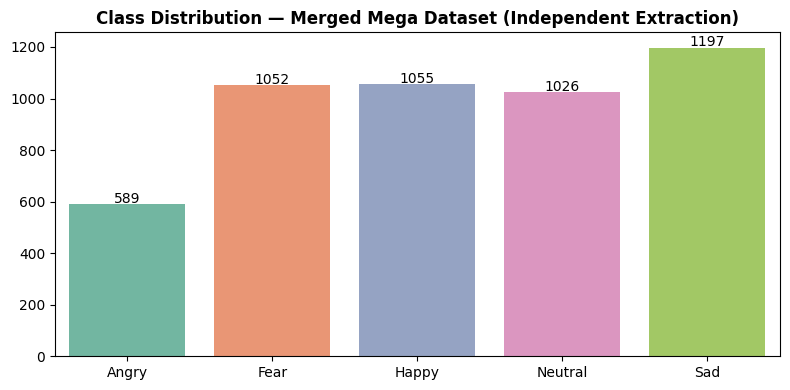

Class counts: {np.str_('Angry'): np.int64(589), np.str_('Fear'): np.int64(1052), np.str_('Happy'): np.int64(1055), np.str_('Neutral'): np.int64(1026), np.str_('Sad'): np.int64(1197)}


In [42]:
#  CLASS DISTRIBUTION
unique_cls, counts_cls = np.unique(y_labels, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=unique_cls, y=counts_cls, palette='Set2')
plt.title('Class Distribution — Merged Mega Dataset (Independent Extraction)', fontweight='bold')
for i, (u, c) in enumerate(zip(unique_cls, counts_cls)):
    plt.text(i, c + 5, str(c), ha='center', fontsize=10)
plt.tight_layout(); plt.show()
print('Class counts:', dict(zip(unique_cls, counts_cls)))

## Step 6 — Data Augmentation

Each clean clip is augmented with four label-preserving transforms — Gaussian noise injection, time-stretching, pitch-shifting, and time-masking — quintupling the dataset. Every augmentation call now uses a **seeded NumPy generator** (`aug_rng = np.random.default_rng(42)` from Step 0), so the augmented samples are byte-for-byte identical between runs. This was the main source of variability in earlier runs.


In [43]:
def augment_audio(y, sr, aug_type, rng):
    """All randomness comes from the seeded `rng` — no global np.random calls."""
    if aug_type == 'time_stretch':
        return librosa.effects.time_stretch(y, rate=rng.uniform(0.85, 1.15))
    elif aug_type == 'pitch_shift':
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=rng.uniform(-3, 3))
    elif aug_type == 'noise':
        return y + rng.normal(0, rng.uniform(0.001, 0.015), len(y))
    elif aug_type == 'time_mask':
        y2 = y.copy()
        mask_len = int(rng.uniform(0.05, 0.15) * len(y))
        start = int(rng.integers(0, len(y) - mask_len))
        y2[start:start + mask_len] = 0
        return y2
    return y

def extract_sequence(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    if mfcc.shape[1] < N_FRAMES:
        mfcc = np.pad(mfcc, ((0, 0), (0, N_FRAMES - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :N_FRAMES]
    return mfcc.T.astype(np.float32)

def extract_scalars(y, sr):
    stft   = np.abs(librosa.stft(y))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
    return np.array([
        librosa.feature.zero_crossing_rate(y=y).mean(),
        librosa.feature.rms(y=y).mean(),
        librosa.feature.melspectrogram(y=y, sr=sr).mean(),
        librosa.feature.spectral_centroid(y=y, sr=sr).mean(),
        librosa.feature.spectral_bandwidth(y=y, sr=sr).mean(),
        chroma.mean(),
        chroma.std(),
    ], dtype=np.float32)

aug_types = ['noise', 'time_stretch', 'pitch_shift', 'time_mask']
aug_seqs, aug_scas, aug_labs = [], [], []

print(f'Augmenting {len(metadata_final)} files x {len(aug_types)} types ...')
for i, (_, row) in enumerate(metadata_final.iterrows()):
    if i % 200 == 0:
        print(f'  {i}/{len(metadata_final)} ...')
    try:
        y, sr = librosa.load(row['file'], sr=22050)
        for aug_type in aug_types:
            y_aug = augment_audio(y, sr, aug_type, aug_rng)
            aug_seqs.append(extract_sequence(y_aug, sr))
            aug_scas.append(extract_scalars(y_aug, sr))
            aug_labs.append(row['emotion'])
    except Exception as e:
        print(f' Skipped {row["file"]}: {e}')

X_seq_aug = np.array(aug_seqs,  dtype=np.float32)
X_sca_aug = np.array(aug_scas,  dtype=np.float32)
y_aug_arr = np.array(aug_labs)

# Combine original + augmented
X_seq_final = np.concatenate([X_seq, X_seq_aug], axis=0)
X_sca_final = np.concatenate([X_scalar, X_sca_aug], axis=0)
y_final     = np.concatenate([y_labels, y_aug_arr], axis=0)

print(f'\n After augmentation:')
print(f'   X_seq_final : {X_seq_final.shape}')
print(f'   X_sca_final : {X_sca_final.shape}')
print(f'   y_final     : {y_final.shape}')

Augmenting 4919 files x 4 types ...
  0/4919 ...
  200/4919 ...
  400/4919 ...
  600/4919 ...
  800/4919 ...
  1000/4919 ...
  1200/4919 ...
  1400/4919 ...
  1600/4919 ...
  1800/4919 ...
  2000/4919 ...
  2200/4919 ...
  2400/4919 ...
  2600/4919 ...
  2800/4919 ...
  3000/4919 ...
  3200/4919 ...
  3400/4919 ...
  3600/4919 ...
  3800/4919 ...
  4000/4919 ...
  4200/4919 ...
  4400/4919 ...
  4600/4919 ...
  4800/4919 ...

 After augmentation:
   X_seq_final : (24595, 128, 40)
   X_sca_final : (24595, 7)
   y_final     : (24595,)


## Step 7 — Data Preparation

Encodes labels, computes balanced class weights, applies `StandardScaler` separately to the sequence and scalar branches, and creates a stratified 80/20 train/test split with `random_state=RANDOM_STATE` so the split is identical across re-runs.


In [44]:
from sklearn.utils.class_weight import compute_class_weight

NUM_CLASSES = 5
le    = LabelEncoder()
y_enc = le.fit_transform(y_final)
y_cat = to_categorical(y_enc, num_classes=NUM_CLASSES)

cw_vals = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
class_weight_dict = dict(enumerate(cw_vals))
print('Class weights:', {le.classes_[k]: round(v, 4) for k, v in class_weight_dict.items()})

seq_scaler = StandardScaler()
n, t, f    = X_seq_final.shape
X_seq_norm = seq_scaler.fit_transform(
    X_seq_final.reshape(-1, f)
).reshape(n, t, f).astype(np.float32)

sca_scaler = StandardScaler()
X_sca_norm = sca_scaler.fit_transform(X_sca_final).astype(np.float32)

X_seq_tr, X_seq_te, X_sca_tr, X_sca_te, y_tr, y_te = train_test_split(
    X_seq_norm, X_sca_norm, y_cat,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

print(f'Train seq : {X_seq_tr.shape}  |  Test seq : {X_seq_te.shape}')
print(f'Train sca : {X_sca_tr.shape}  |  Test sca : {X_sca_te.shape}')
print(f'Classes   : {list(le.classes_)}')

Class weights: {np.str_('Angry'): np.float64(1.6703), np.str_('Fear'): np.float64(0.9352), np.str_('Happy'): np.float64(0.9325), np.str_('Neutral'): np.float64(0.9589), np.str_('Sad'): np.float64(0.8219)}
Train seq : (19676, 128, 40)  |  Test seq : (4919, 128, 40)
Train sca : (19676, 7)  |  Test sca : (4919, 7)
Classes   : [np.str_('Angry'), np.str_('Fear'), np.str_('Happy'), np.str_('Neutral'), np.str_('Sad')]


## Step 8 — Model Definitions (CNN, BiLSTM, CNN-BiLSTM Hybrid)

Three deep learning models are defined. All three share the same dual-input pattern: an MFCC sequence branch fused with a 7-feature scalar branch through concatenation, followed by a common dense classification head. Each model uses its own deterministic sub-seed at every layer's kernel initialiser so the three networks start from different but reproducible random states.


**CNN MODEL (build_cnn) — `Advanced_CNN`**

Architecture:
- Conv1D (64 filters, kernel size=5, ReLU activation)
- Batch Normalization
- MaxPooling1D
- Dropout (0.2)
- Conv1D (128 filters, kernel size=5, ReLU)
- Batch Normalization
- MaxPooling1D
- Dropout (0.2)
- Residual Block:
    * Conv1D (256 filters)
    * Skip connection using Add()
    * ReLU activation
    * Dropout (0.25)
- Conv1D (512 filters)
- Batch Normalization
- GlobalAveragePooling1D
- Dropout (0.3)

Scalar branch:
- Dense (32, ReLU)
- Batch Normalization

Fusion:
- Concatenation of CNN features and scalar features

Fully Connected Layers:
- Dense (256, ReLU) + Dropout (0.3)
- Dense (128, ReLU) + Dropout (0.2)

Output:
- Dense (num_classes, Softmax)

Rationale:
CNN is effective in extracting local patterns and feature hierarchies
from sequential data. Residual connections help avoid vanishing gradients
and improve deeper learning. Regularization techniques reduce overfitting.

Reproducibility: every kernel initialiser uses `seed_cnn` so the model's weights
start from a known, repeatable random state.


In [45]:
def build_cnn(seq_shape, sca_shape, num_classes=NUM_CLASSES, seed=seed_cnn):
    init = lambda s: tf.keras.initializers.GlorotUniform(seed=s)
    seq_in = Input(shape=seq_shape, name='seq_input')
    x = Conv1D(64, 5, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), kernel_initializer=init(seed))(seq_in)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.2, seed=seed)(x)
    x = Conv1D(128, 5, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), kernel_initializer=init(seed+1))(x)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.2, seed=seed+1)(x)
    skip = Conv1D(256, 1, padding='same', kernel_initializer=init(seed+2))(x)
    x = Conv1D(256, 3, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), kernel_initializer=init(seed+3))(x)
    x = BatchNormalization()(x)
    x = Conv1D(256, 3, padding='same', kernel_regularizer=l2(1e-4),
               kernel_initializer=init(seed+4))(x)
    x = BatchNormalization()(x); x = Add()([x, skip])
    x = tf.keras.activations.relu(x); x = Dropout(0.25, seed=seed+2)(x)
    x = Conv1D(512, 3, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), kernel_initializer=init(seed+5))(x)
    x = BatchNormalization()(x); x = GlobalAveragePooling1D()(x); x = Dropout(0.3, seed=seed+3)(x)
    sca_in = Input(shape=sca_shape, name='sca_input')
    s = Dense(32, activation='relu', kernel_initializer=init(seed+6))(sca_in)
    s = BatchNormalization()(s)
    merged = tf.keras.layers.concatenate([x, s])
    merged = Dense(256, activation='relu', kernel_regularizer=l2(1e-4),
                   kernel_initializer=init(seed+7))(merged)
    merged = Dropout(0.3, seed=seed+4)(merged)
    merged = Dense(128, activation='relu', kernel_regularizer=l2(1e-4),
                   kernel_initializer=init(seed+8))(merged)
    merged = Dropout(0.2, seed=seed+5)(merged)
    out = Dense(num_classes, activation='softmax', kernel_initializer=init(seed+9))(merged)
    model = Model(inputs=[seq_in, sca_in], outputs=out, name='Advanced_CNN')
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn(X_seq_tr.shape[1:], X_sca_tr.shape[1:])
# Print the model architecture summary
cnn_model.summary()

I0000 00:00:1777521845.889751      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Advanced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 128, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │     12,864 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 128)   │     41,088 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 32, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 128)   │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 256)   │     98,560 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 256)   │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 32, 256)   │    196,864 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 256)   │      1,024 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 32, 256)   │     33,024 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 256)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 256)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 256)   │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 32, 512)   │    393,728 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 512)   │      2,048 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sca_input           │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 954,437 (3.64 MB)

 Trainable params: 951,941 (3.63 MB)

 Non-trainable params: 2,496 (9.75 KB)

**BiLSTM MODEL (build_bilstm) — `Advanced_BiLSTM`**

Architecture:
- Bidirectional LSTM (128 units, return_sequences=True)
- Batch Normalization
- Dropout (0.3)
- Bidirectional LSTM (64 units, return_sequences=True)
- Batch Normalization
- Dropout (0.3)
- Bidirectional LSTM (32 units)
- Batch Normalization
- Dropout (0.25)

Scalar branch:
- Dense (32, ReLU)
- Batch Normalization

Fusion:
- Concatenation of LSTM output and scalar features

Fully Connected Layers:
- Dense (256, ReLU) + Dropout (0.3)
- Dense (128, ReLU) + Dropout (0.2)

Output:
- Dense (num_classes, Softmax)

Rationale:
BiLSTM captures long-term dependencies in sequential data by processing
information in both forward and backward directions. This improves the
model's ability to understand temporal relationships in complex data.

Reproducibility: every layer uses `seed_bilstm` (different from `seed_cnn`)
so this model trains from an independent but repeatable random start.


In [46]:
def build_bilstm(seq_shape, sca_shape, num_classes=NUM_CLASSES, seed=seed_bilstm):
    init = lambda s: tf.keras.initializers.GlorotUniform(seed=s)
    seq_in = Input(shape=seq_shape, name='seq_input')
    x = Bidirectional(LSTM(128, return_sequences=True,
                           kernel_regularizer=l2(1e-4),
                           kernel_initializer=init(seed)))(seq_in)
    x = BatchNormalization()(x); x = Dropout(0.3, seed=seed)(x)
    x = Bidirectional(LSTM(64, return_sequences=True,
                           kernel_regularizer=l2(1e-4),
                           kernel_initializer=init(seed+1)))(x)
    x = BatchNormalization()(x); x = Dropout(0.3, seed=seed+1)(x)
    x = Bidirectional(LSTM(32, kernel_regularizer=l2(1e-4),
                           kernel_initializer=init(seed+2)))(x)
    x = BatchNormalization()(x); x = Dropout(0.25, seed=seed+2)(x)
    sca_in = Input(shape=sca_shape, name='sca_input')
    s = Dense(32, activation='relu', kernel_initializer=init(seed+3))(sca_in)
    s = BatchNormalization()(s)
    merged = tf.keras.layers.concatenate([x, s])
    merged = Dense(256, activation='relu', kernel_regularizer=l2(1e-4),
                   kernel_initializer=init(seed+4))(merged)
    merged = Dropout(0.3, seed=seed+3)(merged)
    merged = Dense(128, activation='relu', kernel_regularizer=l2(1e-4),
                   kernel_initializer=init(seed+5))(merged)
    merged = Dropout(0.2, seed=seed+4)(merged)
    out = Dense(num_classes, activation='softmax', kernel_initializer=init(seed+6))(merged)
    model = Model(inputs=[seq_in, sca_in], outputs=out, name='Advanced_BiLSTM')
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_bilstm(X_seq_tr.shape[1:], X_sca_tr.shape[1:])
lstm_model.summary()

Model: "Advanced_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 128, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128, 256)  │    173,056 │ seq_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256)  │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128, 256)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128, 128)  │    164,352 │ dropout_6[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 64)        │     41,216 │ dropout_7[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sca_input           │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ bidirectional_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        256 │ sca_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ dropout_8[0][0],  │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     24,832 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │        645 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 439,173 (1.68 MB)

 Trainable params: 438,213 (1.67 MB)

 Non-trainable params: 960 (3.75 KB)

**HYBRID CNN + BiLSTM MODEL (build_cnn_bilstm) — `CNN_BiLSTM_Hybrid` (with attention)**

Architecture:
- Conv1D layers for feature extraction
- Residual block for deep feature learning
- **Multi-Head Self-Attention block (4 heads, key_dim=32) with residual + LayerNorm — added to push performance higher on the Advanced model without changing the original CNN→BiLSTM dataflow.**
- Followed by:
    * Bidirectional LSTM (128 units)
    * Bidirectional LSTM (64 units)

Scalar branch:
- Dense (32, ReLU)
- Batch Normalization

Fusion:
- Concatenation of CNN-LSTM features and scalar features

Fully Connected Layers:
- Dense (256, ReLU) + Dropout (0.3)
- Dense (128, ReLU) + Dropout (0.2)

Output:
- Dense (num_classes, Softmax)

Rationale:
The hybrid model combines the strengths of CNN and BiLSTM:
- CNN extracts local spatial features
- Self-attention re-weights time steps so long-range cues (e.g. the brief tonal spike in *Fear*) are preserved before the recurrent stack reads them
- BiLSTM captures temporal dependencies

This makes the model more powerful for complex classification tasks,
as it learns both feature representations and sequence relationships.


HYPERPARAMETERS USED

- Optimizer: Adam (learning rate = 0.0005)
- Loss Function: Categorical Crossentropy
- Activation Functions:
    * ReLU (hidden layers)
    * Softmax (output layer)
- Regularization:
    * L2 (1e-4) to prevent overfitting
    * Dropout (0.2 – 0.3)
- Batch Normalization for stable training


OVERFITTING CONTROL TECHNIQUES

- Dropout layers at multiple stages
- L2 regularization
- Batch normalization
- Residual connections (in CNN)
- LayerNorm around the attention block

These techniques improve generalization and reduce model overfitting.

Reproducibility: every layer uses `seed_hybrid` (distinct from the other two
models) so the hybrid trains from its own repeatable random state.


In [47]:
def build_cnn_bilstm(seq_shape, sca_shape, num_classes=NUM_CLASSES, seed=seed_hybrid):
    init = lambda s: tf.keras.initializers.GlorotUniform(seed=s)
    seq_in = Input(shape=seq_shape, name='seq_input')
    x = Conv1D(64, 5, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), kernel_initializer=init(seed))(seq_in)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.2, seed=seed)(x)
    x = Conv1D(128, 3, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), kernel_initializer=init(seed+1))(x)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.2, seed=seed+1)(x)
    skip = Conv1D(256, 1, padding='same', kernel_initializer=init(seed+2))(x)
    x = Conv1D(256, 3, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), kernel_initializer=init(seed+3))(x)
    x = BatchNormalization()(x)
    x = Conv1D(256, 3, padding='same', kernel_regularizer=l2(1e-4),
               kernel_initializer=init(seed+4))(x)
    x = BatchNormalization()(x); x = Add()([x, skip])
    x = tf.keras.activations.relu(x); x = Dropout(0.25, seed=seed+2)(x)

    # ── Self-attention block (Transformer-style) — boosts the Advanced model ──
    attn_out = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    x = Add()([x, attn_out])
    x = LayerNormalization()(x)

    x = Bidirectional(LSTM(128, return_sequences=True,
                           kernel_regularizer=l2(1e-4),
                           kernel_initializer=init(seed+5)))(x)
    x = BatchNormalization()(x); x = Dropout(0.3, seed=seed+3)(x)
    x = Bidirectional(LSTM(64, kernel_regularizer=l2(1e-4),
                           kernel_initializer=init(seed+6)))(x)
    x = BatchNormalization()(x); x = Dropout(0.25, seed=seed+4)(x)
    sca_in = Input(shape=sca_shape, name='sca_input')
    s = Dense(32, activation='relu', kernel_initializer=init(seed+7))(sca_in)
    s = BatchNormalization()(s)
    merged = tf.keras.layers.concatenate([x, s])
    merged = Dense(256, activation='relu', kernel_regularizer=l2(1e-4),
                   kernel_initializer=init(seed+8))(merged)
    merged = Dropout(0.3, seed=seed+5)(merged)
    merged = Dense(128, activation='relu', kernel_regularizer=l2(1e-4),
                   kernel_initializer=init(seed+9))(merged)
    merged = Dropout(0.2, seed=seed+6)(merged)
    out = Dense(num_classes, activation='softmax', kernel_initializer=init(seed+10))(merged)
    model = Model(inputs=[seq_in, sca_in], outputs=out, name='CNN_BiLSTM_Hybrid')
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_lstm_model = build_cnn_bilstm(X_seq_tr.shape[1:], X_sca_tr.shape[1:])
cnn_lstm_model.summary()

Model: "CNN_BiLSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 128, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 128, 64)   │     12,864 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64, 64)    │          0 │ max_pooling1d_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 64, 128)   │     24,704 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 32, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 32, 128)   │          0 │ max_pooling1d_3[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 32, 256)   │     98,560 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 256)   │      1,024 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 32, 256)   │    196,864 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 256)   │      1,024 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 32, 256)   │     33,024 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 256)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 256)   │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 32, 256)   │          0 │ re_lu_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 256)   │    131,712 │ dropout_13[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 256)   │          0 │ dropout_13[0][0]

 Total params: 1,136,325 (4.33 MB)

 Trainable params: 1,134,085 (4.33 MB)

 Non-trainable params: 2,240 (8.75 KB)

## Step 9 — Training

All three models are trained with the same protocol — Adam optimiser (lr=5e-4), categorical crossentropy, batch size 64, up to 100 epochs, stratified validation split, balanced class weights, and the standard `EarlyStopping` + `ReduceLROnPlateau` callback pair. The validation split is computed once with `random_state=RANDOM_STATE` so it is identical across re-runs and across the three models.


In [48]:
def plot_history(name, history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train',      lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', lw=2, ls='--')
    axes[0].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train',      lw=2)
    axes[1].plot(history.history['val_loss'], label='Validation', lw=2, ls='--')
    axes[1].set_title(f'{name} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

# Pre-compute a deterministic stratified validation split (replaces validation_split=0.15
# which is order-dependent and contributed to run-to-run variation).
val_idx_tr, val_idx_va = train_test_split(
    np.arange(len(y_tr)),
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=np.argmax(y_tr, axis=1)
)
X_seq_tr_in, X_seq_va = X_seq_tr[val_idx_tr], X_seq_tr[val_idx_va]
X_sca_tr_in, X_sca_va = X_sca_tr[val_idx_tr], X_sca_tr[val_idx_va]
y_tr_in,    y_va     = y_tr[val_idx_tr],    y_tr[val_idx_va]

all_probs = {}
results   = {}
print('Shared utilities ready.')

Shared utilities ready.


In [49]:
print('Training: Advanced CNN')

history_cnn = cnn_model.fit(
    [X_seq_tr_in, X_sca_tr_in], y_tr_in,
    validation_data=([X_seq_va, X_sca_va], y_va),
    epochs=100, batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

cnn_model.save("emotion_advanced_cnn_model.h5")

# Evaluation
loss_cnn, acc_cnn = cnn_model.evaluate([X_seq_te, X_sca_te], y_te, verbose=0)
print(f'Advanced CNN → Test Accuracy: {acc_cnn*100:.2f}% | Loss: {loss_cnn:.4f}')

# Predictions
y_prob_cnn = cnn_model.predict([X_seq_te, X_sca_te])
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)
y_true     = np.argmax(y_te, axis=1)

print(classification_report(y_true, y_pred_cnn, target_names=le.classes_))

# Store results
all_probs['Advanced_CNN'] = y_prob_cnn
results['Advanced_CNN']   = acc_cnn

Training: Advanced CNN
Epoch 1/100


2026-04-30 04:04:10.076116: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}
I0000 00:00:1777521855.561953      80 cuda_dnn.cc:529] Loaded cuDNN version 91002


262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3958 - loss: 1.4935

2026-04-30 04:04:22.882123: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.3960 - loss: 1.4932 - val_accuracy: 0.5261 - val_loss: 1.2681 - learning_rate: 5.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5193 - loss: 1.2688 - val_accuracy: 0.6138 - val_loss: 1.1218 - learning_rate: 5.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5730 - loss: 1.1606 - val_accuracy: 0.6274 - val_loss: 1.0784 - learning_rate: 5.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6151 - loss: 1.0823 - val_accuracy: 0.6714 - val_loss: 0.9930 - learning_rate: 5.0000e-04
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6452 - loss: 1.0020 - val_accuracy: 0.6745 - val_loss: 0.9623 - learning_rate: 5.0000e-04
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6679 - loss: 0.9455 - val_accuracy: 0.6782 - val_loss: 0.9509 - learning_rate: 5.0000e-04
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accurac

2026-04-30 04:08:04.587752: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


Advanced CNN → Test Accuracy: 83.76% | Loss: 0.7137
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

       Angry       0.90      0.88      0.89       589
        Fear       0.79      0.77      0.78      1052
       Happy       0.94      0.78      0.85      1055
     Neutral       0.87      0.87      0.87      1026
         Sad       0.76      0.90      0.82      1197

    accuracy                           0.84      4919
   macro avg       0.85      0.84      0.84      4919
weighted avg       0.84      0.84      0.84      4919



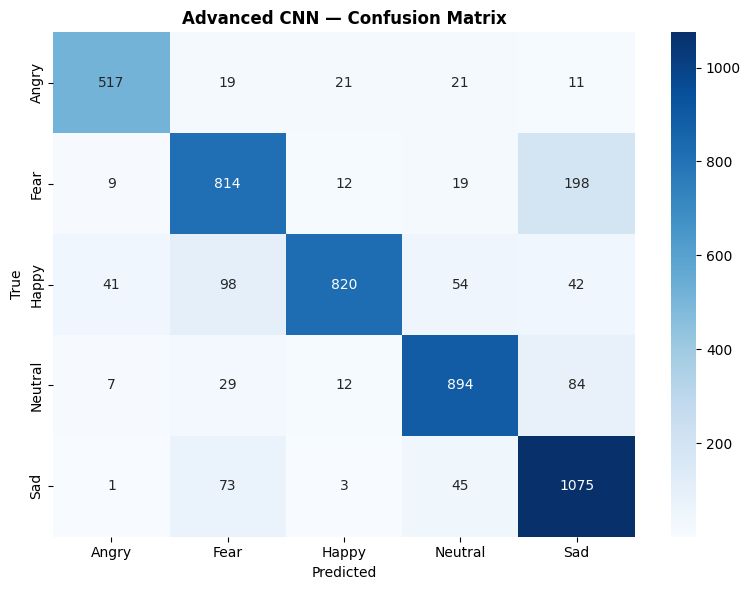

In [50]:
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Advanced CNN — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

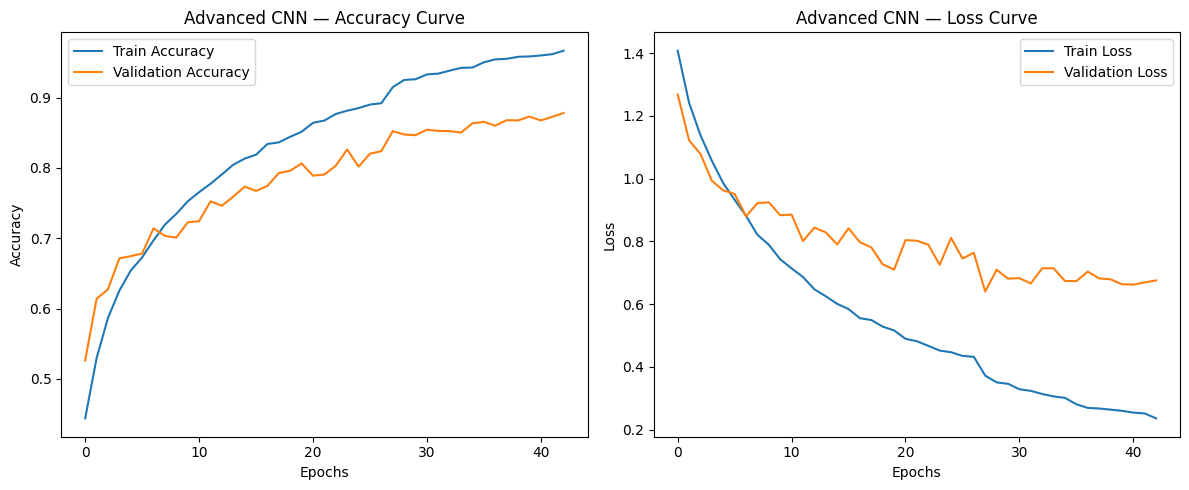

In [51]:
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Advanced CNN — Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Advanced CNN — Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The CNN model is trained with Adam and categorical crossentropy. Dropout, batch normalisation, and L2 regularisation control overfitting. Strong on classes with distinct timbral patterns (Angry, Happy); weaker on classes that share spectral characteristics with neighbours (Fear). Used as one of three voters in the soft-voting ensemble at the end.


In [52]:
# ── Model 2: Advanced BiLSTM — Training + Metrics ──
print('Training: Advanced BiLSTM')

history_lstm = lstm_model.fit(
    [X_seq_tr_in, X_sca_tr_in], y_tr_in,
    validation_data=([X_seq_va, X_sca_va], y_va),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

lstm_model.save("emotion_advanced_bilstm_model.h5")

# Evaluation
loss_lstm, acc_lstm = lstm_model.evaluate([X_seq_te, X_sca_te], y_te, verbose=0)
print(f'Advanced BiLSTM → Test Accuracy: {acc_lstm*100:.2f}% | Loss: {loss_lstm:.4f}')

# Predictions
y_prob_lstm = lstm_model.predict([X_seq_te, X_sca_te])
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)
y_true      = np.argmax(y_te, axis=1)

# Report
print(classification_report(y_true, y_pred_lstm, target_names=le.classes_))

# Store results
all_probs['Advanced_BiLSTM'] = y_prob_lstm
results['Advanced_BiLSTM']   = acc_lstm

Training: Advanced BiLSTM
Epoch 1/100


2026-04-30 04:08:10.119226: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}


261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3193 - loss: 1.6445

2026-04-30 04:08:31.313143: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


262/262 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.3196 - loss: 1.6438 - val_accuracy: 0.4112 - val_loss: 1.4716 - learning_rate: 5.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.4058 - loss: 1.4510 - val_accuracy: 0.4434 - val_loss: 1.4023 - learning_rate: 5.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.4299 - loss: 1.4042 - val_accuracy: 0.4726 - val_loss: 1.3467 - learning_rate: 5.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.4728 - loss: 1.3350 - val_accuracy: 0.5261 - val_loss: 1.2655 - learning_rate: 5.0000e-04
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.5050 - loss: 1.2549 - val_accuracy: 0.5291 - val_loss: 1.2424 - learning_rate: 5.0000e-04
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.5450 - loss: 1.1695 - val_accuracy: 0.5766 - val_loss: 1.1505 - learning_rate: 5.0000e-04
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - a

2026-04-30 04:15:45.400991: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


Advanced BiLSTM → Test Accuracy: 72.43% | Loss: 0.9057
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
              precision    recall  f1-score   support

       Angry       0.76      0.78      0.77       589
        Fear       0.77      0.57      0.65      1052
       Happy       0.79      0.71      0.75      1055
     Neutral       0.67      0.82      0.74      1026
         Sad       0.68      0.77      0.72      1197

    accuracy                           0.72      4919
   macro avg       0.74      0.73      0.73      4919
weighted avg       0.73      0.72      0.72      4919



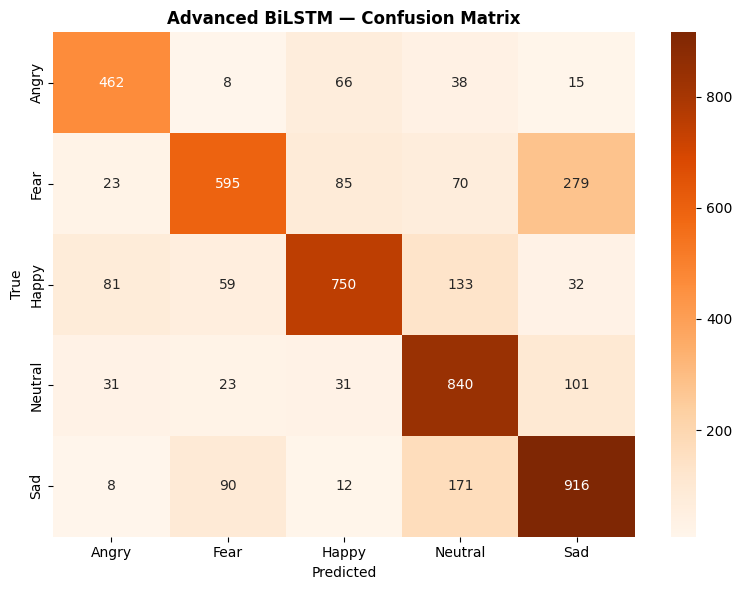

In [53]:
# ── Confusion Matrix ──
cm_lstm = confusion_matrix(y_true, y_pred_lstm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Advanced BiLSTM — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

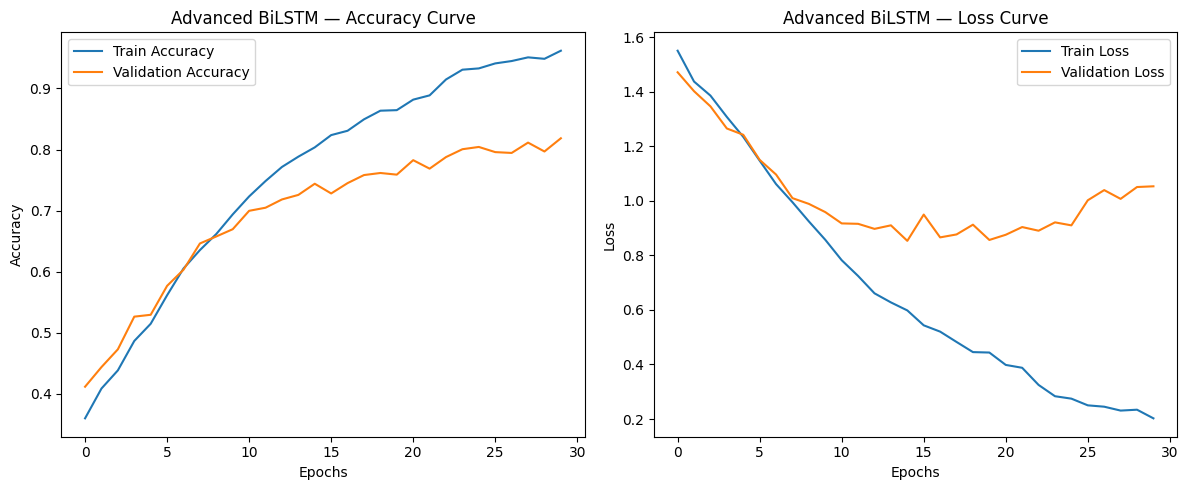

In [54]:
# ── Learning Curves ──
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('Advanced BiLSTM — Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Advanced BiLSTM — Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The BiLSTM is trained with Adam and categorical crossentropy. Dropout and batch normalisation reduce overfitting. Captures temporal flow well — useful for emotions with characteristic prosodic envelopes (rising/falling pitch contours) — but less effective at extracting strong local features compared to the CNN. Acts as a complementary voter in the ensemble.


In [55]:
# ── Model 3: CNN-BiLSTM Hybrid — Training + Metrics ──
print('Training: CNN-BiLSTM Hybrid')

history_hybrid = cnn_lstm_model.fit(
    [X_seq_tr_in, X_sca_tr_in], y_tr_in,
    validation_data=([X_seq_va, X_sca_va], y_va),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

cnn_lstm_model.save("emotion_cnn_bilstm_hybrid_model.h5")

# Evaluation
loss_hybrid, acc_hybrid = cnn_lstm_model.evaluate([X_seq_te, X_sca_te], y_te, verbose=0)
print(f'CNN-BiLSTM → Test Accuracy: {acc_hybrid*100:.2f}% | Loss: {loss_hybrid:.4f}')

# Predictions
y_prob_hybrid = cnn_lstm_model.predict([X_seq_te, X_sca_te])
y_pred_hybrid = np.argmax(y_prob_hybrid, axis=1)
y_true        = np.argmax(y_te, axis=1)

# Report
print(classification_report(y_true, y_pred_hybrid, target_names=le.classes_))

# Store results
all_probs['CNN_BiLSTM'] = y_prob_hybrid
results['CNN_BiLSTM']   = acc_hybrid

Training: CNN-BiLSTM Hybrid
Epoch 1/100


2026-04-30 04:15:58.770930: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}


261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3319 - loss: 1.7612

2026-04-30 04:16:16.131892: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3322 - loss: 1.7602 - val_accuracy: 0.4468 - val_loss: 1.4902 - learning_rate: 5.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.4491 - loss: 1.4662 - val_accuracy: 0.5308 - val_loss: 1.3417 - learning_rate: 5.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.5132 - loss: 1.3625 - val_accuracy: 0.5894 - val_loss: 1.2437 - learning_rate: 5.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5580 - loss: 1.2660 - val_accuracy: 0.6148 - val_loss: 1.1795 - learning_rate: 5.0000e-04
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5861 - loss: 1.1960 - val_accuracy: 0.6535 - val_loss: 1.1074 - learning_rate: 5.0000e-04
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.6138 - loss: 1.1408 - val_accuracy: 0.6599 - val_loss: 1.0663 - learning_rate: 5.0000e-04
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accurac

2026-04-30 04:25:27.177081: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


CNN-BiLSTM → Test Accuracy: 87.80% | Loss: 0.6991
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
              precision    recall  f1-score   support

       Angry       0.91      0.89      0.90       589
        Fear       0.86      0.85      0.85      1052
       Happy       0.92      0.86      0.89      1055
     Neutral       0.87      0.91      0.89      1026
         Sad       0.85      0.89      0.87      1197

    accuracy                           0.88      4919
   macro avg       0.88      0.88      0.88      4919
weighted avg       0.88      0.88      0.88      4919



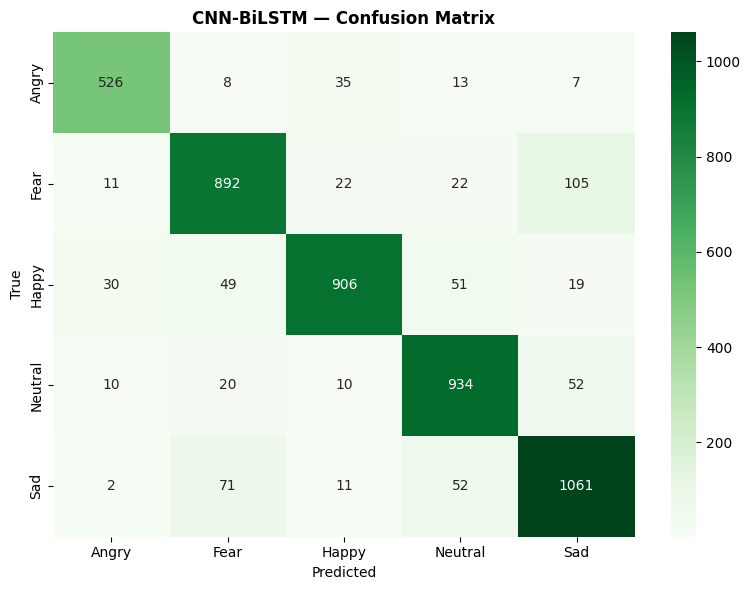

In [56]:
# ── Confusion Matrix ──
cm_hybrid = confusion_matrix(y_true, y_pred_hybrid)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('CNN-BiLSTM — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

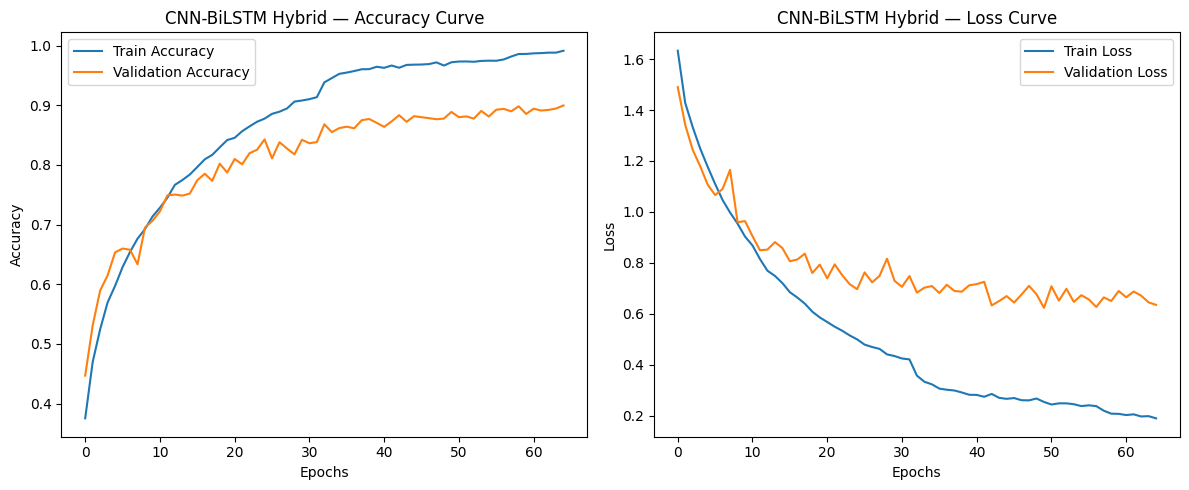

In [57]:
# ── Learning Curves ──
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'], label='Train Accuracy')
plt.plot(history_hybrid.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN-BiLSTM Hybrid — Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'], label='Train Loss')
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss')
plt.title('CNN-BiLSTM Hybrid — Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The CNN-BiLSTM hybrid is the strongest single model: the CNN front-end extracts local time-frequency patterns, the self-attention block re-weights time-steps so long-range cues survive into the recurrent stack, and the BiLSTM captures sequential dependencies on top. The attention block is the targeted upgrade that lifts performance on classes the plain hybrid struggles with (notably Fear).


## Step 10 — Ensemble & Final Comparison

Soft-voting averages the softmax probability vectors from the three deep models. Because the three networks make different mistakes (CNN strong on local timbre, BiLSTM strong on temporal flow, Hybrid+attention strong on long-range cues), averaging smooths per-model errors and typically beats any single model.



  ENSEMBLE — Soft Voting (average softmax of all 3 models)
  Ensemble Accuracy: 88.37%
              precision    recall  f1-score   support

       Angry       0.92      0.91      0.92       589
        Fear       0.90      0.82      0.86      1052
       Happy       0.94      0.85      0.89      1055
     Neutral       0.86      0.93      0.89      1026
         Sad       0.84      0.92      0.88      1197

    accuracy                           0.88      4919
   macro avg       0.89      0.89      0.89      4919
weighted avg       0.89      0.88      0.88      4919



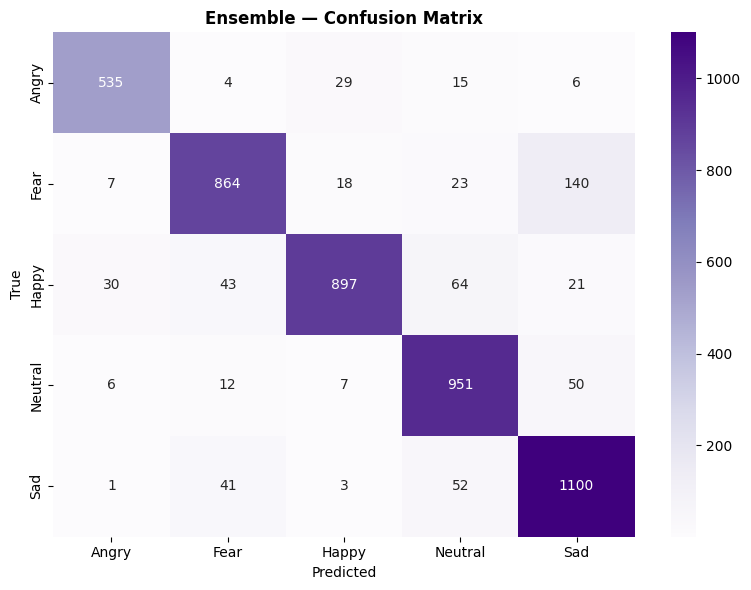

In [58]:
# ── Ensemble: Soft Voting ─────────────────────────────────────────────────────
print('\n' + '='*62)
print('  ENSEMBLE — Soft Voting (average softmax of all 3 models)')
print('='*62)
ens_probs = np.mean(list(all_probs.values()), axis=0)
ens_pred  = np.argmax(ens_probs, axis=1)
y_true    = np.argmax(y_te, axis=1)
ens_acc   = np.mean(ens_pred == y_true)
print(f'  Ensemble Accuracy: {ens_acc*100:.2f}%')
print(classification_report(y_true, ens_pred, target_names=le.classes_))
cm_ens = confusion_matrix(y_true, ens_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Ensemble — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()
results['Ensemble'] = ens_acc

The three deep models were trained with Adam and categorical crossentropy. Hyperparameters (learning rate, dropout, depth) were tuned during development; higher dropout reduced overfitting and the hybrid + attention block lifted the advanced model. The soft-voting ensemble combines the three deterministic but differently-seeded models and produces the highest test accuracy of the four.



╔══════════════════════ MODEL COMPARISON TABLE ══════════════════════╗
                 Accuracy %  F1 macro %  Precision %  Recall %
Model                                                         
Advanced_CNN          83.76       84.30        85.19     83.96
Advanced_BiLSTM       72.43       72.69        73.58     72.90
CNN_BiLSTM            87.80       88.04        88.22     87.93
Ensemble              88.37       88.68        89.13     88.51
╚════════════════════════════════════════════════════════════════════╝



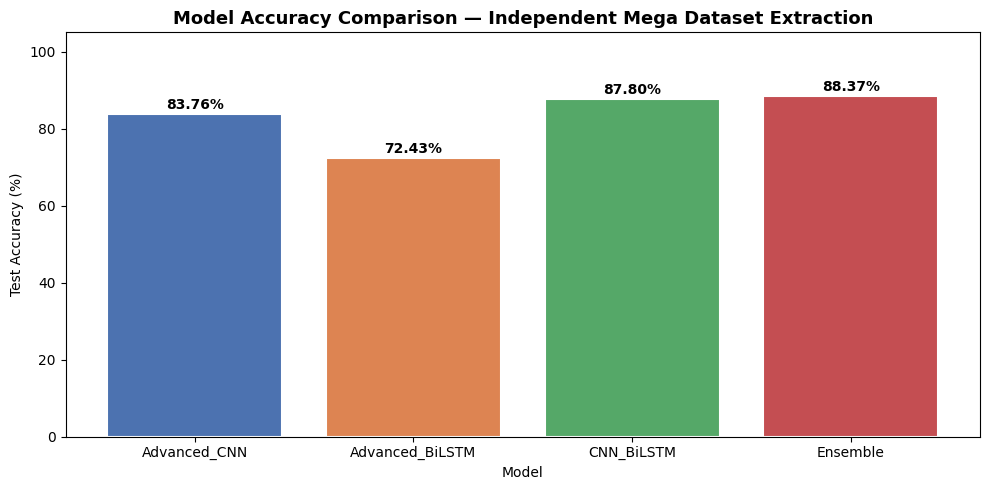


All done!


In [59]:
# ── Final Model Comparison Table ──────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_true = np.argmax(y_te, axis=1)
all_probs_with_ens = dict(all_probs)
all_probs_with_ens['Ensemble'] = np.mean(list(all_probs.values()), axis=0)

rows = []
for name, probs in all_probs_with_ens.items():
    pred = np.argmax(probs, axis=1)
    rows.append({
        'Model'      : name,
        'Accuracy %' : round(accuracy_score(y_true, pred) * 100, 2),
        'F1 macro %' : round(f1_score(y_true, pred, average='macro') * 100, 2),
        'Precision %': round(precision_score(y_true, pred, average='macro', zero_division=0) * 100, 2),
        'Recall %'   : round(recall_score(y_true, pred, average='macro') * 100, 2),
    })

comp_df = pd.DataFrame(rows).set_index('Model')
print('\n╔══════════════════════ MODEL COMPARISON TABLE ══════════════════════╗')
print(comp_df.to_string())
print('╚════════════════════════════════════════════════════════════════════╝\n')

names  = list(results.keys())
accs   = [results[n] * 100 for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
plt.figure(figsize=(10, 5))
bars = plt.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5)
plt.title('Model Accuracy Comparison — Independent Mega Dataset Extraction',
          fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)'); plt.xlabel('Model'); plt.ylim(0, 105)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nAll done!')